In [34]:
#%pip install matplotlib, seaborn, scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 478.8 kB/s  0:00:19 eta 0:00:010:01:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 471.0 kB/s  0:01:14 eta 0:00:010:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn]0m 5/6 [scikit-learn]]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_from_disk


In [2]:
    
    # 1. Загрузка модели и данных
    #model_path = "tencent/HY-MT1.5-1.8B"
    model_path = "/home/user/.cache/huggingface/hub/models--tencent--HY-MT1.5-1.8B/snapshots/dbad03788f49709801014c95d481a514c272ca52"
    
    tokenizer = AutoTokenizer.from_pretrained(model_path
                                              #, padding_side='left'
                                             )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.float16,
        device_map="auto"
    )


[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'alpha', 'beta_slow', 'mscale', 'mscale_all_dim', 'beta_fast'}
[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'alpha', 'beta_slow', 'mscale', 'mscale_all_dim', 'beta_fast'}
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

In [3]:
SYSTEM_PROMPT = "把英语翻译成俄：{text}"
layers = range(model.config.num_hidden_layers)  # 24 слоя (0-23)
model.config.num_hidden_layers

32

In [4]:
source ='123'
system_prompt = "把英语翻译成俄：{text}"
prompt = system_prompt.format(text=source)
prompt

'把英语翻译成俄：123'

In [5]:
train_dataset = load_from_disk("./wmt14_ru_en_500_samples")

In [4]:
def get_activations_single(text, tokenizer, model, layers):
    """
    Снимает активации для одного текста на указанных слоях.
    Использует output_hidden_states вместо хуков.
    
    Returns:
        dict: {layer_idx: tensor(1, hidden_dim)}
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    
    # Forward pass с сохранением всех скрытых состояний
    with torch.no_grad():
        #outputs = model(inputs.input_ids, output_hidden_states=True)
        outputs = model(**inputs, output_hidden_states=True)
    
    # outputs.hidden_states — это кортеж из (embeddings, layer_1, ..., layer_N)
    # Индексация: 0 — эмбеддинги, 1 — слой 0, 2 — слой 1, ...
    layer_activations = {}
    for layer_idx in layers:
        # +1 потому что первый элемент — эмбеддинги
        hidden_state = outputs.hidden_states[layer_idx + 1]
        
        # Берем последний токен (если размерность 3) или все как есть (если 2)
        if hidden_state.dim() == 3:
            layer_activations[layer_idx] = hidden_state[:, -1, :].detach().cpu()
        else:
            layer_activations[layer_idx] = hidden_state.detach().cpu()
    
    return layer_activations

In [14]:
def collect_activations_no_batch(dataset, tokenizer, model, layers, max_examples=500):
    """
    Собирает активации для английских и русских текстов по одному примеру.
    
    Returns:
        dict: {
            'en': {layer_idx: tensor(N, hidden_dim)},
            'ru': {layer_idx: tensor(N, hidden_dim)}
        }
    """
    # Ограничиваем количество примеров
    if max_examples and max_examples < len(dataset):
        dataset = dataset.select(range(max_examples))
    
    print(f"📊 Обработка {len(dataset)} примеров по одному...")
    
    # Словари для хранения активаций
    en_activations = {layer: [] for layer in layers}
    ru_activations = {layer: [] for layer in layers}
    
    # Обходим датасет по одному примеру
    for idx in tqdm(range(len(dataset)), desc="Сбор активаций"):
        example = dataset[idx]
        en_text = example['translation']['en']
        ru_text = example['translation']['ru']
        
        # Собираем активации для английского текста
        en_activ = get_activations_single(en_text, tokenizer, model, layers)
        
        # Собираем активации для русского текста
        ru_activ = get_activations_single(ru_text, tokenizer, model, layers)
        
        # Сохраняем активации
        for layer in layers:
            en_activations[layer].append(en_activ[layer])
            ru_activations[layer].append(ru_activ[layer])
        
    
    # Объединяем все примеры в один тензор для каждого слоя
    for layer in layers:
        en_activations[layer] = torch.cat(en_activations[layer], dim=0)
        ru_activations[layer] = torch.cat(ru_activations[layer], dim=0)
    
    print(f"✅ Собраны активации для {len(dataset)} примеров")
    print(f"   Размерность EN: {en_activations[layers[0]].shape}")
    print(f"   Размерность RU: {ru_activations[layers[0]].shape}")
    
    return {'en': en_activations, 'ru': ru_activations}

import torch
import os

def save_activations(activations, output_dir="./activations"):
    """
    Сохраняет собранные активации в отдельные файлы.
    
    Args:
        activations: dict от collect_activations_no_batch
        output_dir: папка для сохранения
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Сохраняем английские активации
    en_path = os.path.join(output_dir, "en_activations.pt")
    torch.save(activations['en'], en_path)
    print(f"✅ Сохранены английские активации в {en_path}")
    
    # Сохраняем русские активации
    ru_path = os.path.join(output_dir, "ru_activations.pt")
    torch.save(activations['ru'], ru_path)
    print(f"✅ Сохранены русские активации в {ru_path}")
    
    # Также сохраняем информацию о слоях для справки
    info = {
        'layers': list(activations['en'].keys()),
        'num_examples': activations['en'][list(activations['en'].keys())[0]].shape[0],
        'hidden_dim': activations['en'][list(activations['en'].keys())[0]].shape[1]
    }
    
    info_path = os.path.join(output_dir, "activations_info.json")
    import json
    with open(info_path, 'w') as f:
        json.dump(info, f, indent=2)
    print(f"✅ Сохранена информация в {info_path}")

# === ИСПОЛЬЗОВАНИЕ ===

layers = range(model.config.num_hidden_layers)  # 24 слоя (0-23)
# После сбора активаций
activations = collect_activations_no_batch(
    dataset=train_dataset,
    tokenizer=tokenizer,
    model=model,
    layers=layers,
    max_examples=500
)

# Сохраняем активации
#save_activations(activations, output_dir="./activations_data_500")

print("\n📁 Структура сохраненных файлов:")
print("  activations_data/")
print("    ├── en_activations.pt      # Активации для английских текстов")
print("    ├── ru_activations.pt      # Активации для русских текстов")
print("    └── activations_info.json  # Мета-информация")

📊 Обработка 500 примеров по одному...


Сбор активаций: 100%|████████████████████████| 500/500 [00:35<00:00, 14.11it/s]


✅ Собраны активации для 500 примеров
   Размерность EN: torch.Size([500, 2048])
   Размерность RU: torch.Size([500, 2048])
✅ Сохранены английские активации в ./activations_data_500/en_activations.pt
✅ Сохранены русские активации в ./activations_data_500/ru_activations.pt
✅ Сохранена информация в ./activations_data_500/activations_info.json

📁 Структура сохраненных файлов:
  activations_data/
    ├── en_activations.pt      # Активации для английских текстов
    ├── ru_activations.pt      # Активации для русских текстов
    └── activations_info.json  # Мета-информация


In [6]:
import torch
import os
import json
from typing import Dict, List
def load_activations(
    input_dir: str = "./activations_data_500"
) -> Dict[str, Dict[int, torch.Tensor]]:
    """
    Загружает сохраненные активации из папки.
    
    Returns:
        dict: {'en': {layer: tensor}, 'ru': {layer: tensor}}
    """
    en_path = os.path.join(input_dir, "en_activations.pt")
    ru_path = os.path.join(input_dir, "ru_activations.pt")
    info_path = os.path.join(input_dir, "activations_info.json")
    
    # Загружаем активации
    en_activations = torch.load(en_path, map_location='cpu')
    ru_activations = torch.load(ru_path, map_location='cpu')
    
    print(f"✅ Загружены английские активации из {en_path}")
    print(f"✅ Загружены русские активации из {ru_path}")
    
    # Загружаем информацию
    if os.path.exists(info_path):
        with open(info_path, 'r') as f:
            info = json.load(f)
        print(f"📊 Информация: {info}")
    
    return {'en': en_activations, 'ru': ru_activations}

# Сохраняем активации
#save_activations(activations, output_dir="./activations_data_500")
activations = load_activations("./activations_data_500")

✅ Загружены английские активации из ./activations_data_500/en_activations.pt
✅ Загружены русские активации из ./activations_data_500/ru_activations.pt
📊 Информация: {'layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], 'num_examples': 500, 'hidden_dim': 2048}


In [7]:
len(activations['ru'][0])

500

In [8]:
def compute_steering_vectors(activations, layers):
    steering_vectors = {}
    for layer in layers:
        en_mean = activations['en'][layer].mean(dim=0, keepdim=True)
        ru_mean = activations['ru'][layer].mean(dim=0, keepdim=True)
        steering_vectors[layer] = ru_mean - en_mean
    return steering_vectors

steering_vectors = compute_steering_vectors(activations, layers)
steering_vectors[0].shape

torch.Size([1, 2048])

📊 Анализ норм стиринг-векторов

Слой 1:
  Норма вектора: 0.0729
  Случайный шум: 0.0204 ± 0.0083
  Отношение сигнал/шум: 3.57x
  EN std: 0.0191, RU std: 0.0198

Слой 2:
  Норма вектора: 0.3259
  Случайный шум: 0.1552 ± 0.1177
  Отношение сигнал/шум: 2.10x
  EN std: 0.0609, RU std: 0.0534

Слой 3:
  Норма вектора: 0.6406
  Случайный шум: 0.2924 ± 0.1967
  Отношение сигнал/шум: 2.19x
  EN std: 0.0998, RU std: 0.0847

Слой 4:
  Норма вектора: 0.6855
  Случайный шум: 0.3408 ± 0.2347
  Отношение сигнал/шум: 2.01x
  EN std: 0.1055, RU std: 0.0891

Слой 5:
  Норма вектора: 0.6855
  Случайный шум: 0.2843 ± 0.2014
  Отношение сигнал/шум: 2.41x
  EN std: 0.1036, RU std: 0.0875

Слой 6:
  Норма вектора: 0.6250
  Случайный шум: 0.2718 ± 0.2078
  Отношение сигнал/шум: 2.30x
  EN std: 0.0971, RU std: 0.0825

Слой 7:
  Норма вектора: 0.0996
  Случайный шум: 0.0371 ± 0.0083
  Отношение сигнал/шум: 2.69x
  EN std: 0.0167, RU std: 0.0162

Слой 8:
  Норма вектора: 0.1278
  Случайный шум: 0.0449 ± 0.0063


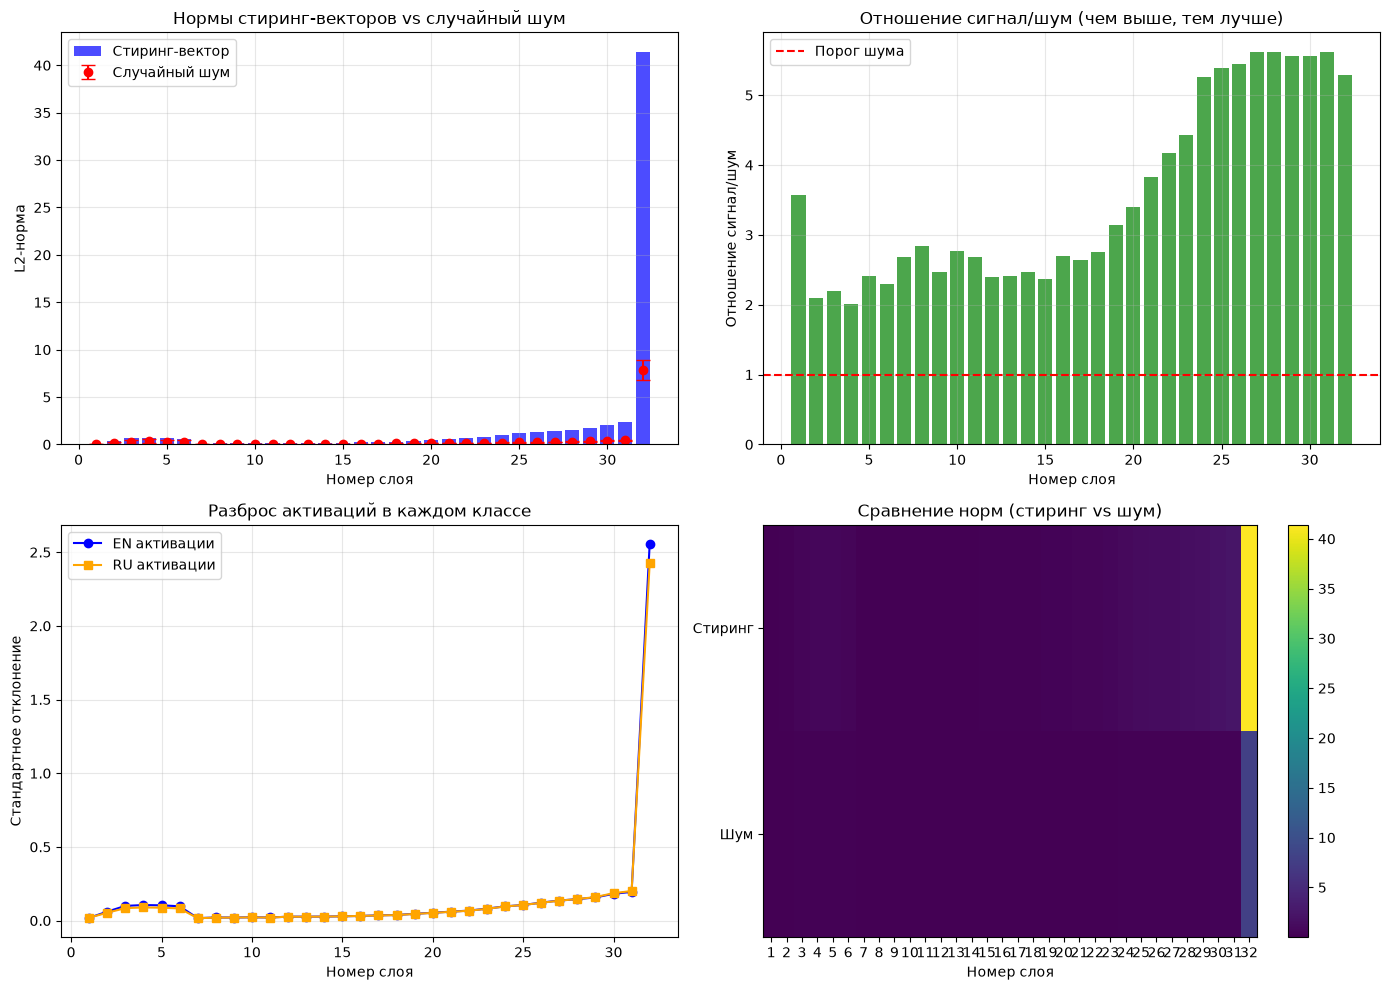

✅ График сохранен как 'steering_analysis.png'


In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

def analyze_steering_vectors(steering_vectors: Dict[int, torch.Tensor], 
                              activations: Dict[str, Dict[int, torch.Tensor]],
                              num_random: int = 100):
    """
    Анализирует стиринг-векторы: вычисляет нормы и сравнивает со случайным шумом.
    
    Args:
        steering_vectors: {layer: tensor(1, hidden_dim)}
        activations: {'en': {layer: tensor(N, hidden_dim)}, 'ru': ...}
        num_random: количество случайных разбиений для оценки шума
    
    Returns:
        dict с результатами анализа
    """
    layers = sorted(steering_vectors.keys())
    hidden_dim = steering_vectors[layers[0]].shape[1]
    
    results = {
        'layers': layers,
        'steering_norms': [],
        'random_norms_mean': [],
        'random_norms_std': [],
        'en_std': [],
        'ru_std': []
    }
    
    print("📊 Анализ норм стиринг-векторов")
    print("="*60)
    
    for layer in layers:
        # 1. Норма стиринг-вектора
        steering_norm = torch.norm(steering_vectors[layer]).item()
        results['steering_norms'].append(steering_norm)
        
        # 2. Оценка случайного шума
        random_norms = []
        en_acts = activations['en'][layer]  # (N, hidden_dim)
        ru_acts = activations['ru'][layer]
        N = en_acts.shape[0]
        
        for _ in range(num_random):
            # Перемешиваем индексы и делим на две случайные группы
            indices = torch.randperm(N)
            half = N // 2
            group1 = en_acts[indices[:half]].mean(dim=0, keepdim=True)
            group2 = en_acts[indices[half:2*half]].mean(dim=0, keepdim=True)
            random_norm = torch.norm(group1 - group2).item()
            random_norms.append(random_norm)
        
        results['random_norms_mean'].append(np.mean(random_norms))
        results['random_norms_std'].append(np.std(random_norms))
        
        # 3. Стандартное отклонение активаций в каждом классе
        results['en_std'].append(en_acts.flatten().std().item())
        results['ru_std'].append(ru_acts.flatten().std().item())
        
        # Вывод информации
        print(f"\nСлой {layer+1}:")
        print(f"  Норма вектора: {steering_norm:.4f}")
        print(f"  Случайный шум: {np.mean(random_norms):.4f} ± {np.std(random_norms):.4f}")
        print(f"  Отношение сигнал/шум: {steering_norm / np.mean(random_norms):.2f}x")
        print(f"  EN std: {results['en_std'][-1]:.4f}, RU std: {results['ru_std'][-1]:.4f}")
    
    return results

def plot_steering_analysis(results: Dict):
    """
    Строит графики для анализа стиринг-векторов.
    """
    layers = results['layers']
    layer_numbers = [l+1 for l in layers]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. График норм со сравнением со случайным шумом
    ax1 = axes[0, 0]
    ax1.bar(layer_numbers, results['steering_norms'], 
            label='Стиринг-вектор', alpha=0.7, color='blue')
    ax1.errorbar(layer_numbers, results['random_norms_mean'], 
                 yerr=results['random_norms_std'], 
                 fmt='o', color='red', label='Случайный шум', capsize=5)
    ax1.set_xlabel('Номер слоя')
    ax1.set_ylabel('L2-норма')
    ax1.set_title('Нормы стиринг-векторов vs случайный шум')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Отношение сигнал/шум
    ax2 = axes[0, 1]
    snr = [s / r for s, r in zip(results['steering_norms'], results['random_norms_mean'])]
    ax2.bar(layer_numbers, snr, color='green', alpha=0.7)
    ax2.axhline(y=1.0, color='red', linestyle='--', label='Порог шума')
    ax2.set_xlabel('Номер слоя')
    ax2.set_ylabel('Отношение сигнал/шум')
    ax2.set_title('Отношение сигнал/шум (чем выше, тем лучше)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Стандартное отклонение активаций
    ax3 = axes[1, 0]
    ax3.plot(layer_numbers, results['en_std'], 'o-', label='EN активации', color='blue')
    ax3.plot(layer_numbers, results['ru_std'], 's-', label='RU активации', color='orange')
    ax3.set_xlabel('Номер слоя')
    ax3.set_ylabel('Стандартное отклонение')
    ax3.set_title('Разброс активаций в каждом классе')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Сравнение норм по слоям (тепловая карта)
    ax4 = axes[1, 1]
    norm_matrix = np.array([
        results['steering_norms'],
        results['random_norms_mean']
    ])
    im = ax4.imshow(norm_matrix, cmap='viridis', aspect='auto')
    ax4.set_xticks(range(len(layer_numbers)))
    ax4.set_xticklabels(layer_numbers)
    ax4.set_yticks([0, 1])
    ax4.set_yticklabels(['Стиринг', 'Шум'])
    ax4.set_xlabel('Номер слоя')
    ax4.set_title('Сравнение норм (стиринг vs шум)')
    plt.colorbar(im, ax=ax4)
    
    plt.tight_layout()
    plt.savefig('steering_analysis.png', dpi=150)
    plt.show()
    print("✅ График сохранен как 'steering_analysis.png'")

# === ИСПОЛЬЗОВАНИЕ ===

# Предположим, у вас уже есть:
# activations = collect_activations_no_batch(...)  # из предыдущего шага
# steering_vectors = compute_steering_vectors(activations, layers)  # из предыдущего шага

# Анализируем
results = analyze_steering_vectors(steering_vectors, activations, num_random=100)

# Строим графики
plot_steering_analysis(results)

📊 АНАЛИЗ АКТИВАЦИЙ (EDA)

📈 БАЗОВЫЕ СТАТИСТИКИ:

Слой 19:
  EN: mean=0.0006, std=0.0463, min=-0.6646, max=1.2480
  RU: mean=0.0008, std=0.0453, min=-0.6367, max=1.1973
  Разница средних: norm=0.3730

Слой 20:
  EN: mean=0.0010, std=0.0533, min=-0.7397, max=1.3984
  RU: mean=0.0011, std=0.0523, min=-0.7310, max=1.3350
  Разница средних: norm=0.4314

Слой 21:
  EN: mean=0.0011, std=0.0607, min=-0.8647, max=1.8838
  RU: mean=0.0014, std=0.0596, min=-0.8130, max=1.8496
  Разница средних: norm=0.5234

Слой 22:
  EN: mean=0.0014, std=0.0679, min=-0.9150, max=2.2969
  RU: mean=0.0015, std=0.0668, min=-0.8735, max=2.2363
  Разница средних: norm=0.6597

Слой 23:
  EN: mean=0.0014, std=0.0812, min=-1.0205, max=2.9277
  RU: mean=0.0015, std=0.0799, min=-0.9697, max=2.9297
  Разница средних: norm=0.7837

Слой 24:
  EN: mean=0.0015, std=0.0966, min=-1.1055, max=3.6680
  RU: mean=0.0018, std=0.0959, min=-1.0439, max=3.7676
  Разница средних: norm=1.0469


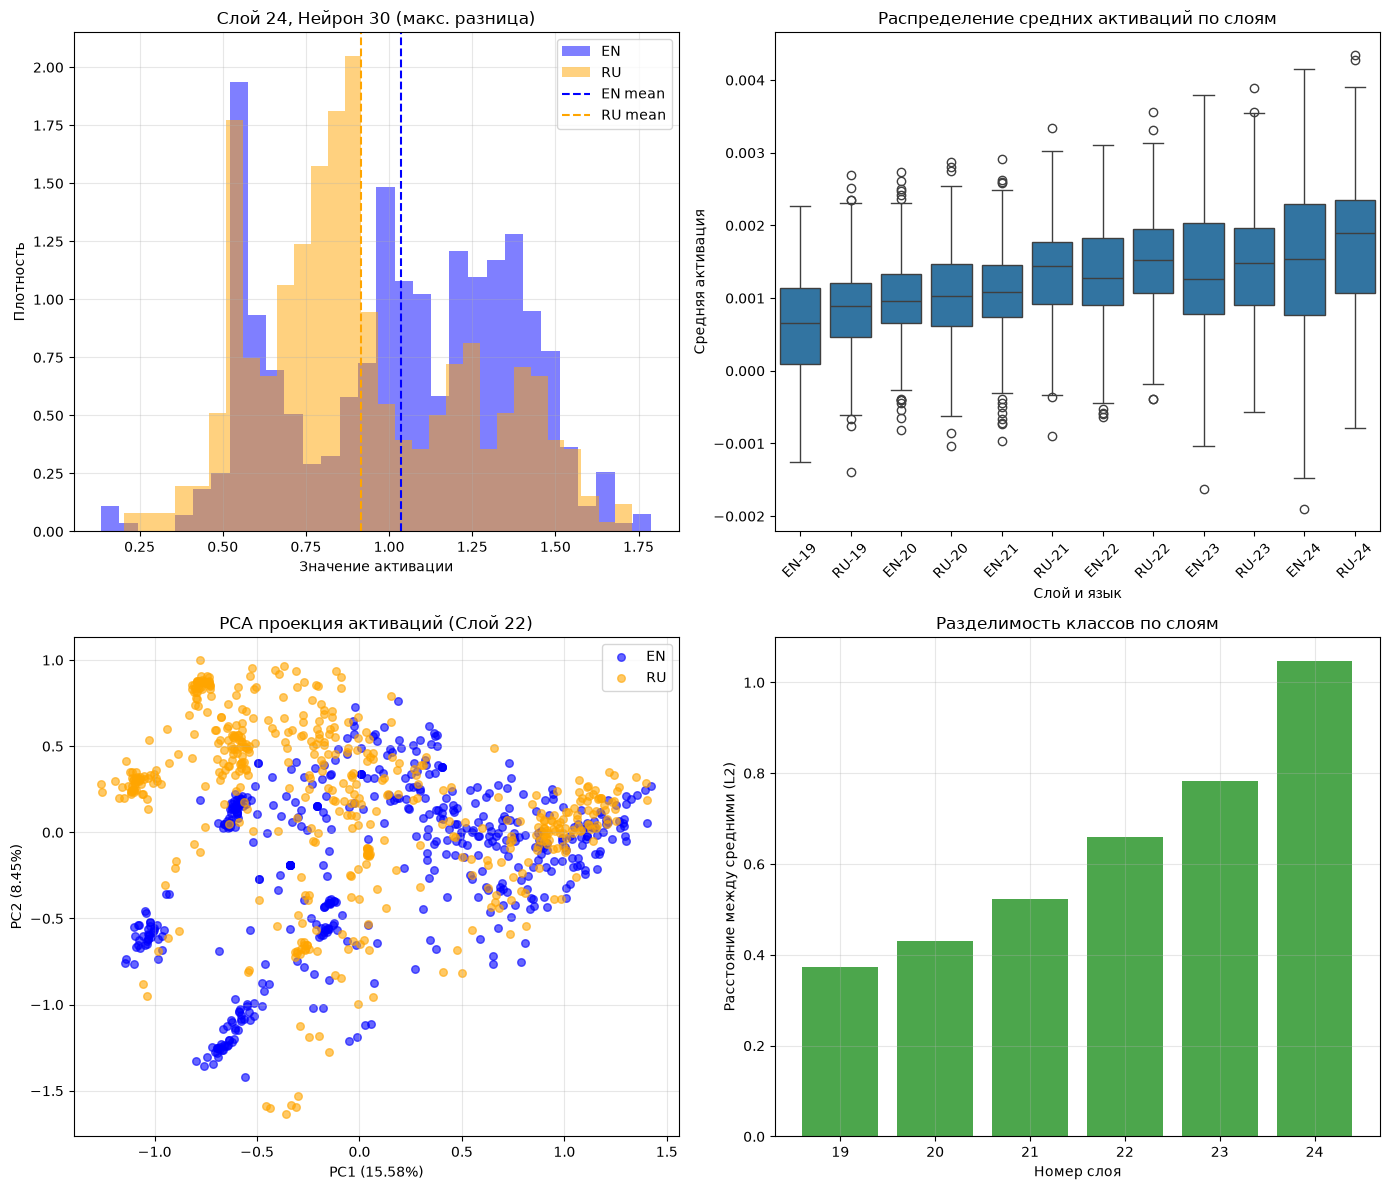


✅ EDA графики сохранены как 'activations_eda.png'

📊 АНАЛИЗ КОСИНУСНОЙ БЛИЗОСТИ МЕЖДУ СЛОЯМИ:


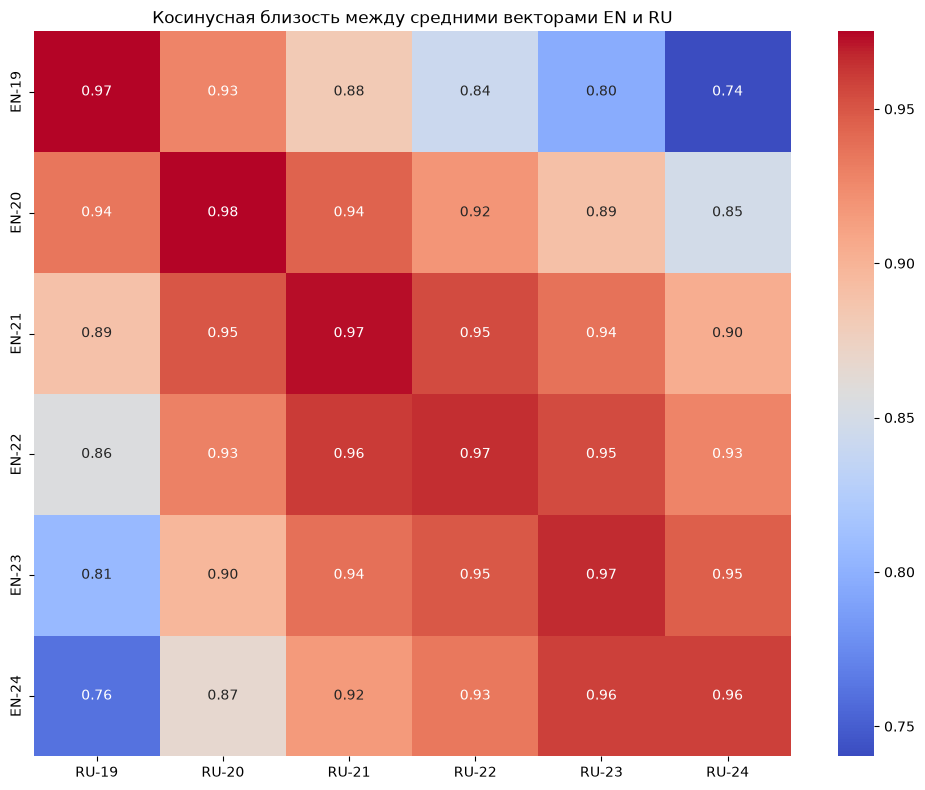

✅ Тепловая карта сохранена как 'cosine_similarity.png'


In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats

def analyze_activations(activations, layers, max_samples=500):
    """
    Проводит EDA активаций для всех слоев.
    
    Args:
        activations: {'en': {layer: tensor(N, hidden_dim)}, 'ru': {layer: tensor(N, hidden_dim)}}
        layers: список слоев для анализа
        max_samples: максимальное количество примеров для визуализации (для PCA/t-SNE)
    """
    print("📊 АНАЛИЗ АКТИВАЦИЙ (EDA)")
    print("="*60)
    
    # Ограничиваем выборку для визуализации
    N = activations['en'][layers[0]].shape[0]
    if max_samples < N:
        indices = torch.randperm(N)[:max_samples]
    else:
        indices = torch.arange(N)
    
    # Собираем активации для всех слоев в один словарь
    en_acts = {layer: activations['en'][layer][indices] for layer in layers}
    ru_acts = {layer: activations['ru'][layer][indices] for layer in layers}
    
    # 1. Базовые статистики
    print("\n📈 БАЗОВЫЕ СТАТИСТИКИ:")
    for layer in layers:
        en_flat = en_acts[layer].flatten()
        ru_flat = ru_acts[layer].flatten()
        
        print(f"\nСлой {layer+1}:")
        print(f"  EN: mean={en_flat.mean():.4f}, std={en_flat.std():.4f}, min={en_flat.min():.4f}, max={en_flat.max():.4f}")
        print(f"  RU: mean={ru_flat.mean():.4f}, std={ru_flat.std():.4f}, min={ru_flat.min():.4f}, max={ru_flat.max():.4f}")
        
        # Разница средних (это и есть потенциальный стиринг-вектор)
        diff_mean = ru_acts[layer].mean(dim=0) - en_acts[layer].mean(dim=0)
        print(f"  Разница средних: norm={torch.norm(diff_mean).item():.4f}")
    
    # 2. Визуализация распределений
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 2.1 Гистограммы распределений (для одного выбранного нейрона)
    # Выбираем нейрон с максимальной разницей средних
    neuron_idx = None
    max_diff = -1
    for layer in layers:
        diff = (ru_acts[layer].mean(dim=0) - en_acts[layer].mean(dim=0)).abs()
        if diff.max() > max_diff:
            max_diff = diff.max()
            neuron_idx = diff.argmax().item()
            best_layer = layer
    
    ax = axes[0, 0]
    en_vals = en_acts[best_layer][:, neuron_idx].numpy()
    ru_vals = ru_acts[best_layer][:, neuron_idx].numpy()
    ax.hist(en_vals, bins=30, alpha=0.5, label='EN', color='blue', density=True)
    ax.hist(ru_vals, bins=30, alpha=0.5, label='RU', color='orange', density=True)
    ax.axvline(np.mean(en_vals), color='blue', linestyle='--', label='EN mean')
    ax.axvline(np.mean(ru_vals), color='orange', linestyle='--', label='RU mean')
    ax.set_xlabel('Значение активации')
    ax.set_ylabel('Плотность')
    ax.set_title(f'Слой {best_layer+1}, Нейрон {neuron_idx} (макс. разница)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2.2 Boxplot по слоям
    ax = axes[0, 1]
    data = []
    labels = []
    for layer in layers:
        # Берем среднее по всем нейронам для каждого примера
        en_mean = en_acts[layer].mean(dim=1).numpy()
        ru_mean = ru_acts[layer].mean(dim=1).numpy()
        data.extend(en_mean)
        data.extend(ru_mean)
        labels.extend([f'EN-{layer+1}'] * len(en_mean))
        labels.extend([f'RU-{layer+1}'] * len(ru_mean))
    
    # Берем только несколько слоев для читаемости
    step = max(1, len(layers) // 6)
    selected_layers = layers[::step]
    data = []
    labels = []
    for layer in selected_layers:
        en_mean = en_acts[layer].mean(dim=1).numpy()
        ru_mean = ru_acts[layer].mean(dim=1).numpy()
        data.extend(en_mean)
        data.extend(ru_mean)
        labels.extend([f'EN-{layer+1}'] * len(en_mean))
        labels.extend([f'RU-{layer+1}'] * len(ru_mean))
    
    import pandas as pd
    df = pd.DataFrame({'value': data, 'group': labels})
    sns.boxplot(x='group', y='value', data=df, ax=ax)
    ax.set_xlabel('Слой и язык')
    ax.set_ylabel('Средняя активация')
    ax.set_title('Распределение средних активаций по слоям')
    ax.tick_params(axis='x', rotation=45)
    
    # 2.3 PCA проекция
    ax = axes[1, 0]
    # Выбираем средний слой для PCA
    mid_layer = layers[len(layers)//2]
    X = torch.cat([en_acts[mid_layer], ru_acts[mid_layer]], dim=0).numpy()
    y = np.array(['EN'] * len(en_acts[mid_layer]) + ['RU'] * len(ru_acts[mid_layer]))
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    colors = {'EN': 'blue', 'RU': 'orange'}
    for label in ['EN', 'RU']:
        mask = y == label
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[label], label=label, alpha=0.6, s=30)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax.set_title(f'PCA проекция активаций (Слой {mid_layer+1})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2.4 Разделимость классов (расстояние между средними)
    ax = axes[1, 1]
    distances = []
    for layer in layers:
        en_mean = en_acts[layer].mean(dim=0)
        ru_mean = ru_acts[layer].mean(dim=0)
        dist = torch.norm(ru_mean - en_mean).item()
        distances.append(dist)
    
    ax.bar([f'{l+1}' for l in layers], distances, color='green', alpha=0.7)
    ax.set_xlabel('Номер слоя')
    ax.set_ylabel('Расстояние между средними (L2)')
    ax.set_title('Разделимость классов по слоям')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('activations_eda.png', dpi=150)
    plt.show()
    print("\n✅ EDA графики сохранены как 'activations_eda.png'")
    
    # 3. Дополнительный анализ: косинусная близость между слоями
    print("\n📊 АНАЛИЗ КОСИНУСНОЙ БЛИЗОСТИ МЕЖДУ СЛОЯМИ:")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Вычисляем средние векторы для каждого слоя и языка
    en_means = {layer: en_acts[layer].mean(dim=0) for layer in layers}
    ru_means = {layer: ru_acts[layer].mean(dim=0) for layer in layers}
    
    # Матрица косинусной близости (EN vs RU)
    cos_sim_matrix = np.zeros((len(layers), len(layers)))
    for i, l1 in enumerate(layers):
        for j, l2 in enumerate(layers):
            cos_sim = torch.nn.functional.cosine_similarity(
                en_means[l1].unsqueeze(0), 
                ru_means[l2].unsqueeze(0)
            ).item()
            cos_sim_matrix[i, j] = cos_sim
    
    sns.heatmap(cos_sim_matrix, 
                xticklabels=[f'RU-{l+1}' for l in layers],
                yticklabels=[f'EN-{l+1}' for l in layers],
                annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
    ax.set_title('Косинусная близость между средними векторами EN и RU')
    plt.tight_layout()
    plt.savefig('cosine_similarity.png', dpi=150)
    plt.show()
    print("✅ Тепловая карта сохранена как 'cosine_similarity.png'")
    
    return {'en_acts': en_acts, 'ru_acts': ru_acts}

# === ИСПОЛЬЗОВАНИЕ ===

# После того как собрали активации:
# activations = collect_activations_no_batch(...)

# Проводим EDA
layers = list(range(18, 24))  # например, поздние слои
eda_results = analyze_activations(activations, layers, max_samples=500)

# Теперь, когда мы понимаем структуру, можно вычислить стиринг-вектор
# Можно попробовать разные методы:
# 1. Простая разность средних (уже есть)
# 2. Разность медиан
# 3. Разность после PCA (только главные компоненты)

In [9]:
import torch
import os
import json
from typing import Dict, List
# для instruct-модели лучше chat template, а не голый промпт


In [10]:
def translate_with_steering(
    text: str,
    tokenizer,
    model,
    steering_vector: torch.Tensor,
    layer_idx: int,
    alpha: float = 1.0,
    system_prompt: str = SYSTEM_PROMPT,
    max_new_tokens: int = 200
) -> str:
    
    prompt = system_prompt.format(text=text)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)

    def pre_hook(module, inputs):
        x = inputs[0]  # [B, S, D]
        v = steering_vector.to(x.device, x.dtype).reshape(1, 1, -1)  # [1, 1, D]
        x_mod = x + v * alpha
        return (x_mod,) + inputs[1:]

    # Вешаем pre-hook на вход указанного слоя
    hook = model.model.layers[layer_idx].register_forward_pre_hook(pre_hook)

    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
    finally:
        hook.remove()

    generated = outputs[0][inputs.input_ids.shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)

    
# === ТЕСТИРОВАНИЕ ===
def test_steering_on_validation(
    dataset,
    tokenizer,
    model,
    steering_vectors: Dict[int, torch.Tensor],
    layers_to_test: List[int],
    alphas: List[float] = [0.0, 0.3, 0.5, 1.0, 1.5, 2.0],
    num_examples: int = 50,
    system_prompt: str = "把英语翻译成俄：{text}",
    max_new_tokens: int = 200,
    output_file: str = None
) -> Dict:
    """
    Тестирует стиринг-векторы на валидационной выборке.
    Сохраняет переводы в JSONL и считает метрики тем же способом, что и baseline.
    
    Returns:
        dict: { (layer, alpha): metrics }
    """
    import os
    from tqdm import tqdm
    
    # Ограничиваем выборку
    if num_examples and num_examples < len(dataset):
        dataset = dataset.select(range(num_examples))
    
    results = {}
    os.makedirs("./outputs", exist_ok=True)
    
    for layer in layers_to_test:
        steering_vector = steering_vectors[layer]
        
        for alpha in alphas:
            print(f"\n📊 Тестирование слоя {layer+1}, alpha={alpha:.3f}")
            print("-" * 40)
            
            # Генерируем переводы
            records = []
            for idx in tqdm(range(len(dataset)), desc=f"Слой {layer+1}, alpha={alpha}"):
                src = dataset[idx]['translation']['en']
                ref = dataset[idx]['translation']['ru']
                
                # Генерация с хуком
                pred = translate_with_steering(
                    text=src,
                    tokenizer=tokenizer,
                    model=model,
                    steering_vector=steering_vector,
                    layer_idx=layer,
                    alpha=alpha,
                    system_prompt=system_prompt,
                    max_new_tokens=max_new_tokens
                )
                
                records.append({
                    'id': idx,
                    'source': src,
                    'reference': ref,
                    'translation': pred
                })
            
            # Сохраняем в JSONL
            if output_file:
                filepath = output_file.format(layer=layer+1, alpha=alpha)
            else:
                filepath = f"./outputs/steering_layer_{layer+1}_alpha_{alpha:.3f}.jsonl"
            
            with open(filepath, 'w', encoding='utf-8') as f:
                for r in records:
                    f.write(json.dumps(r, ensure_ascii=False) + '\n')
            
            # Считаем метрики (тем же способом, что и baseline)
            metrics = compute_metrics_for_translations(records=records)
            results[(layer, alpha)] = metrics
            
            print(f"  BLEU={metrics['bleu']:.2f}, switch_rate={metrics['switch_rate']:.1f}%")
    
    return results

In [11]:
#steering_vector = torch.load("./steering_vectors/steering_layer_24.pt", map_location='cpu')
#if steering_vector.dim() == 2:
steering_vector_tmp = steering_vectors[0] #if alpha=0 no matter what is in steering_vector_tmp 

# Промпт
text = "The quick brown fox jumps over the lazy dog."
system_prompt = SYSTEM_PROMPT
prompt = system_prompt.format(text=text)

print(f"Промпт: {prompt}\n")
# 1. Генерация БЕЗ хука
inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
generated = outputs[0][inputs.input_ids.shape[1]:]
result_no_hook = tokenizer.decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(f"БЕЗ ХУКА: {result_no_hook}")

result_with_hook = translate_with_steering(
                    text, tokenizer, model, steering_vector_tmp, 24, alpha=0.0 #layer_idx (24) no matter too
                )
print(f"С Хуком: {result_with_hook}")


Промпт: 把英语翻译成俄：The quick brown fox jumps over the lazy dog.

БЕЗ ХУКА: 
Быстрый коричневый лис выскакивает через ленивого собаку.


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


С Хуком: 
Быстрый коричневый лис выскакивает через ленивого собаку.


In [10]:
steering_vectors[0]

tensor([[-3.6049e-04,  4.0054e-05,  1.1559e-03,  ...,  2.1591e-03,
         -3.7956e-04,  2.3842e-04]], dtype=torch.float16)

In [12]:
from sacrebleu import corpus_bleu
# === ЗАПУСК ===

# Загружаем валидационный датасет
val_dataset = load_from_disk("./wmt14_ru_en_validation_full")

In [49]:
from sacrebleu import corpus_bleu
# === ЗАПУСК ===

# Загружаем валидационный датасет
val_dataset = load_from_disk("./wmt14_ru_en_validation_full")
#train_dataset = load_from_disk("./wmt14_ru_en_500_samples")

# Тестируем слои 24-31 с разными alpha
#layers_to_test = [23, 24, 25, 26, 27, 28, 29, 30]  # 24-31 слои (индексация с 0)
layers_to_test = [ 23, 27, 30]
alphas = [.001, .005, .01, .02, .035, 0.5, 1.0, 1.5, 2.0, 10.]

results = test_steering_on_validation(
    dataset=dataset_tiny, #val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    layers_to_test=layers_to_test,
    alphas=alphas,
    num_examples=50
)

# Находим лучшую комбинацию
best = max(results.items(), key=lambda x: x[1]['bleu'])
print(f"\n🏆 Лучший результат: слой {best[0][0]+1}, alpha={best[0][1]}")
print(f"   BLEU={best[1]['bleu']:.2f}, съезды={best[1]['switch_rate']:.1f}%")


📊 Тестирование слоя 24, alpha=0.0
----------------------------------------


Слой 24, alpha=0.001: 100%|████████████████████| 12/12 [02:30<00:00, 12.53s/it]


📂 Получено 12 записей напрямую
📊 BLEU: 16.77
📊 chrF: 53.43
📊 Съезды на другие языки: 2 / 12 (16.67%)

📏 Статистика по длине (в словах):
  Источник: средняя 18.5, макс 31, мин 9
  Референс: средняя 15.7, макс 24, мин 6
  Перевод: средняя 29.8, макс 62, мин 10

⚠️ Примеры съездов (первые 2):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation:  in 2016 is to try to make the election a two-way race.
Республиканская стратегия по противодействию...

  [6] Source: Unlike in Canada, the American States are responsible for the organisation of federal elections in t...
      Translation: 

В отличие от Канады, американские штаты несут ответственность за организацию федеральных выборов в...

  BLEU=16.77, съезды=16.7%

📊 Тестирование слоя 24, alpha=0.0
----------------------------------------


Слой 24, alpha=0.005: 100%|████████████████████| 12/12 [02:34<00:00, 12.89s/it]


📂 Получено 12 записей напрямую
📊 BLEU: 16.77
📊 chrF: 53.43
📊 Съезды на другие языки: 2 / 12 (16.67%)

📏 Статистика по длине (в словах):
  Источник: средняя 18.5, макс 31, мин 9
  Референс: средняя 15.7, макс 24, мин 6
  Перевод: средняя 29.8, макс 62, мин 10

⚠️ Примеры съездов (первые 2):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation:  in 2016 is to try to make the election a two-way race.
Республиканская стратегия по противодействию...

  [6] Source: Unlike in Canada, the American States are responsible for the organisation of federal elections in t...
      Translation: 

В отличие от Канады, американские штаты несут ответственность за организацию федеральных выборов в...

  BLEU=16.77, съезды=16.7%

📊 Тестирование слоя 24, alpha=0.0
----------------------------------------


...

📂 Получено 12 записей напрямую
📊 BLEU: 4.81
📊 chrF: 34.70
📊 Съезды на другие языки: 0 / 12 (0.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 18.5, макс 31, мин 9
  Референс: средняя 15.7, макс 24, мин 6
  Перевод: средняя 35.9, макс 101, мин 10
  BLEU=4.81, съезды=0.0%

📊 Тестирование слоя 31, alpha=2.0
----------------------------------------


Слой 31, alpha=2.0: 100%|██████████████████████| 12/12 [05:07<00:00, 25.59s/it]


📂 Получено 12 записей напрямую
📊 BLEU: 0.54
📊 chrF: 12.11
📊 Съезды на другие языки: 0 / 12 (0.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 18.5, макс 31, мин 9
  Референс: средняя 15.7, макс 24, мин 6
  Перевод: средняя 82.1, макс 182, мин 11
  BLEU=0.54, съезды=0.0%

📊 Тестирование слоя 31, alpha=10.0
----------------------------------------


Слой 31, alpha=10.0: 100%|█████████████████████| 12/12 [06:06<00:00, 30.52s/it]

📂 Получено 12 записей напрямую
📊 BLEU: 0.02
📊 chrF: 0.17
📊 Съезды на другие языки: 0 / 12 (0.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 18.5, макс 31, мин 9
  Референс: средняя 15.7, макс 24, мин 6
  Перевод: средняя 200.0, макс 200, мин 200
  BLEU=0.02, съезды=0.0%

🏆 Лучший результат: слой 31, alpha=0.5
   BLEU=23.50, съезды=8.3%


In [13]:
from sacrebleu import corpus_bleu
# === ЗАПУСК ===

# Загружаем валидационный датасет
val_dataset = load_from_disk("./wmt14_ru_en_validation_full")
#train_dataset = load_from_disk("./wmt14_ru_en_500_samples")

# Тестируем слои 24-31 с разными alpha
layers_to_test = [23, 24, 25, 26, 27, 28, 29, 30]  # 24-31 слои (индексация с 0)
#layers_to_test = [ 23, 27, 30]
alphas = [.45, 0.5, 0.55]

results = test_steering_on_validation(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    layers_to_test=layers_to_test,
    alphas=alphas,
    num_examples=50
)

# Находим лучшую комбинацию
best = max(results.items(), key=lambda x: x[1]['bleu'])
print(f"\n🏆 Лучший результат: слой {best[0][0]+1}, alpha={best[0][1]}")
print(f"   BLEU={best[1]['bleu']:.2f}, съезды={best[1]['switch_rate']:.1f}%")


📊 Тестирование слоя 24, alpha=0.5
----------------------------------------


Слой 24, alpha=0.45: 100%|█████████████████████| 50/50 [09:59<00:00, 12.00s/it]


📂 Получено 50 записей напрямую
📊 BLEU: 18.97
📊 chrF: 52.97
📊 Съезды на другие языки: 5 / 50 (10.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.4, макс 35, мин 4
  Референс: средняя 15.7, макс 32, мин 5
  Перевод: средняя 26.8, макс 109, мин 2

⚠️ Примеры съездов (первые 5):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation:  in 2012....

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      Translation:  There are many other things that can be done to make the process of learning a lan

Слой 24, alpha=0.5: 100%|██████████████████████| 50/50 [09:51<00:00, 11.83s/it]


📂 Получено 50 записей напрямую
📊 BLEU: 18.71
📊 chrF: 53.20
📊 Съезды на другие языки: 5 / 50 (10.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.4, макс 35, мин 4
  Референс: средняя 15.7, макс 32, мин 5
  Перевод: средняя 26.3, макс 109, мин 5

⚠️ Примеры съездов (первые 5):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия противодействия переизбранию Об...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      Trans

...

📂 Получено 50 записей напрямую
📊 BLEU: 19.87
📊 chrF: 54.19
📊 Съезды на другие языки: 6 / 50 (12.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.4, макс 35, мин 4
  Референс: средняя 15.7, макс 32, мин 5
  Перевод: средняя 27.2, макс 113, мин 4

⚠️ Примеры съездов (первые 6):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record in office.
Республиканская стратегия противодействия переизбра...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the state of Texas passed a law that made it mandatory for all voters to present ...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court held that the state's law was not unconstitutional, and that the state's actions were in ...

  [23] Source: And that's not all....
      Trans

Слой 31, alpha=0.5: 100%|██████████████████████| 50/50 [09:55<00:00, 11.91s/it]


📂 Получено 50 записей напрямую
📊 BLEU: 17.62
📊 chrF: 51.88
📊 Съезды на другие языки: 7 / 50 (14.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.4, макс 35, мин 4
  Референс: средняя 15.7, макс 32, мин 5
  Перевод: средняя 29.3, макс 153, мин 4

⚠️ Примеры съездов (первые 7):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record in office.
Республиканская стратегия противодействия переизбра...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the state of Texas passed a law that made it mandatory for all voters to present ...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court held that the state's law was not unconstitutional, and that the state's law was in accor...

  [17] Source: It is important to note that, unli

Слой 31, alpha=0.55: 100%|█████████████████████| 50/50 [10:14<00:00, 12.29s/it]

📂 Получено 50 записей напрямую
📊 BLEU: 17.80
📊 chrF: 51.87
📊 Съезды на другие языки: 7 / 50 (14.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.4, макс 35, мин 4
  Референс: средняя 15.7, макс 32, мин 5
  Перевод: средняя 28.8, макс 98, мин 4

⚠️ Примеры съездов (первые 7):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president’s record in office.
Республиканская стратегия противодействия переизбра...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the state of Texas passed a law that made it mandatory for all voters to present ...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court held that the state's law was not in violation of the Constitution. However, the court di...

  [17] Source: It is important to note that, unlik

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

def save_results_to_csv(results: Dict[Tuple[int, float], Dict], output_file: str = "./outputs/steering_results.csv"):
    """
    Сохраняет результаты в CSV-файл.
    """
    rows = []
    for (layer, alpha), metrics in results.items():
        rows.append({
            'layer': layer + 1,
            'layer_idx': layer,
            'alpha': alpha,
            'bleu': metrics['bleu'],
            'chrf': metrics['chrf'],
            'switch_rate': metrics['switch_rate'],
            'switch_count': metrics['switch_count'],
            'total_examples': metrics['total_examples']
        })
    
    df = pd.DataFrame(rows)
    df = df.sort_values(['layer', 'alpha'])
    df.to_csv(output_file, index=False)
    print(f"✅ Результаты сохранены в {output_file}")
    return df

def plot_steering_results(
    results: Dict[Tuple[int, float], Dict],
    baseline_metrics: Dict = None,
    save_path: str = "./outputs/steering_plots.png"
):
    """
    Строит графики для визуализации результатов стиринг-векторов.
    """
    rows = []
    for (layer, alpha), metrics in results.items():
        rows.append({
            'layer': layer + 1,
            'alpha': alpha,
            'bleu': metrics['bleu'],
            'chrf': metrics['chrf'],
            'switch_rate': metrics['switch_rate']
        })
    
    df = pd.DataFrame(rows)
    layers = sorted(df['layer'].unique())
    
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. BLEU
    ax1 = axes[0, 0]
    for layer in layers:
        layer_df = df[df['layer'] == layer]
        ax1.plot(layer_df['alpha'], layer_df['bleu'], marker='o', label=f'Слой {layer}')
    if baseline_metrics:
        ax1.axhline(y=baseline_metrics['bleu'], color='red', linestyle='--', label=f'Baseline BLEU={baseline_metrics["bleu"]:.2f}')
    ax1.set_xlabel('Alpha')
    ax1.set_ylabel('BLEU')
    ax1.set_title('BLEU vs Alpha')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. chrF
    ax2 = axes[0, 1]
    for layer in layers:
        layer_df = df[df['layer'] == layer]
        ax2.plot(layer_df['alpha'], layer_df['chrf'], marker='s', label=f'Слой {layer}')
    if baseline_metrics:
        ax2.axhline(y=baseline_metrics['chrf'], color='red', linestyle='--', label=f'Baseline chrF={baseline_metrics["chrf"]:.2f}')
    ax2.set_xlabel('Alpha')
    ax2.set_ylabel('chrF')
    ax2.set_title('chrF vs Alpha')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. % съездов
    ax3 = axes[1, 0]
    for layer in layers:
        layer_df = df[df['layer'] == layer]
        ax3.plot(layer_df['alpha'], layer_df['switch_rate'], marker='^', label=f'Слой {layer}')
    if baseline_metrics:
        ax3.axhline(y=baseline_metrics['switch_rate'], color='red', linestyle='--', label=f'Baseline switch={baseline_metrics["switch_rate"]:.1f}%')
    ax3.set_xlabel('Alpha')
    ax3.set_ylabel('Съезды, %')
    ax3.set_title('Съезды vs Alpha')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Тепловая карта BLEU
    ax4 = axes[1, 1]
    pivot = df.pivot(index='layer', columns='alpha', values='bleu')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis', ax=ax4, cbar_kws={'label': 'BLEU'})
    ax4.set_title('Тепловая карта BLEU (слой vs alpha)')
    ax4.set_xlabel('Alpha')
    ax4.set_ylabel('Слой')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✅ График сохранён в {save_path}")



✅ Результаты сохранены в ./outputs/steering_results_45_50_55.csv


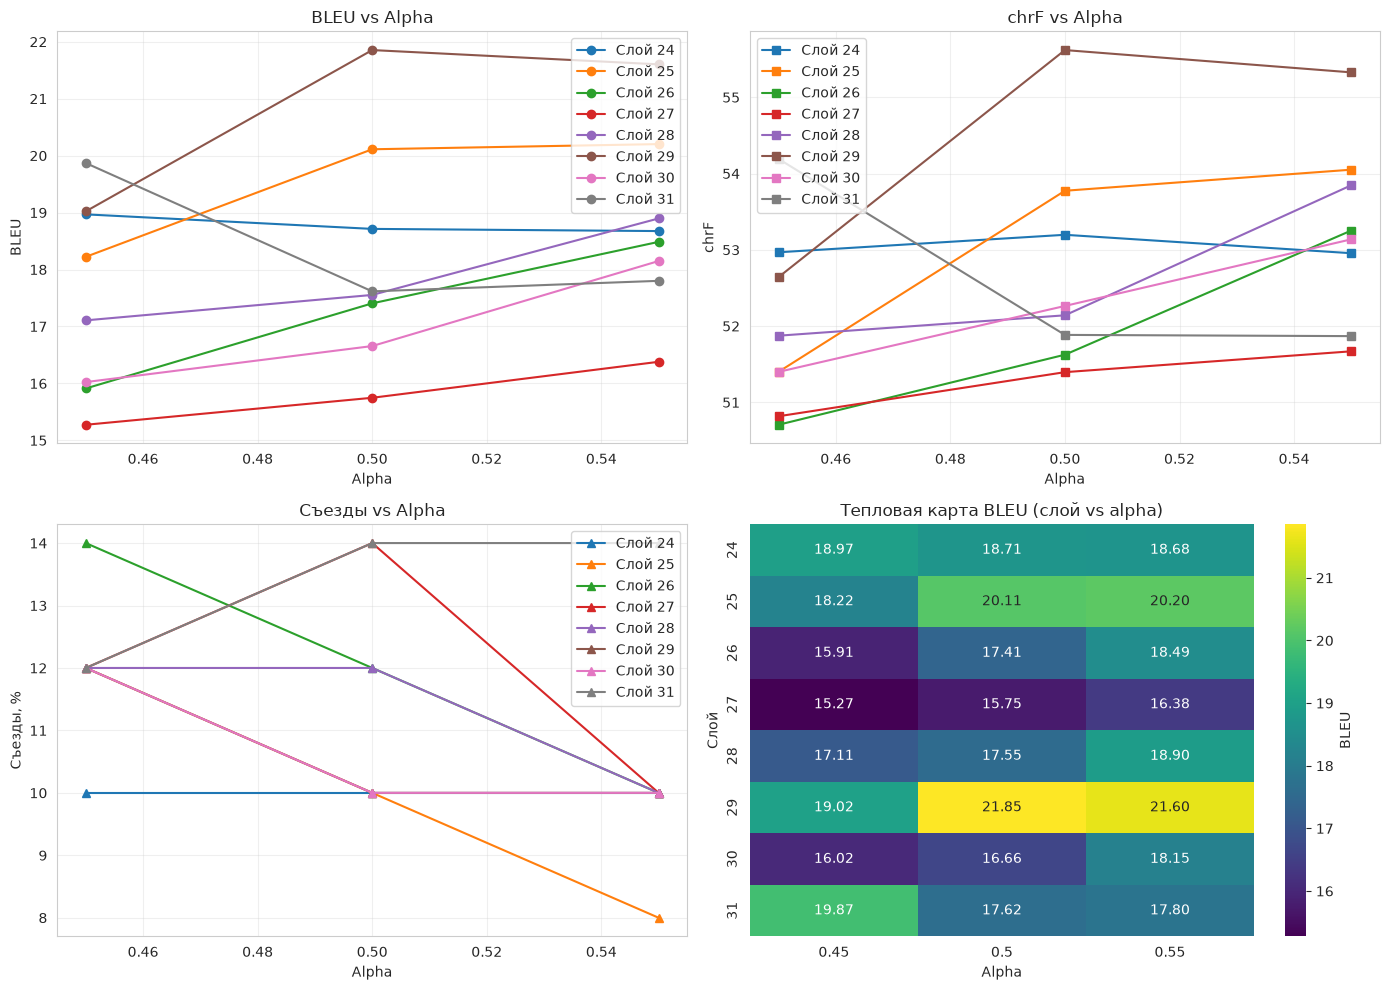

✅ График сохранён в ./outputs/steering_plots_45_50_55.png


In [19]:
df_results = save_results_to_csv(results, "./outputs/steering_results_45_50_55.csv")
plot_steering_results(results, save_path="./outputs/steering_plots_45_50_55.png")

In [16]:
for (layer, alpha), metrics in results.items():
    print(f"Слой {layer+1}, alpha={alpha:.1f}: BLEU={metrics['bleu']:.2f}, съезды={metrics['switch_rate']:.1f}%")

Слой 24, alpha=0.5: BLEU=18.97, съезды=10.0%
Слой 24, alpha=0.5: BLEU=18.71, съезды=10.0%
Слой 24, alpha=0.6: BLEU=18.68, съезды=10.0%
Слой 25, alpha=0.5: BLEU=18.22, съезды=12.0%
Слой 25, alpha=0.5: BLEU=20.11, съезды=10.0%
Слой 25, alpha=0.6: BLEU=20.20, съезды=8.0%
Слой 26, alpha=0.5: BLEU=15.91, съезды=14.0%
Слой 26, alpha=0.5: BLEU=17.41, съезды=12.0%
Слой 26, alpha=0.6: BLEU=18.49, съезды=10.0%
Слой 27, alpha=0.5: BLEU=15.27, съезды=12.0%
Слой 27, alpha=0.5: BLEU=15.75, съезды=14.0%
Слой 27, alpha=0.6: BLEU=16.38, съезды=10.0%
Слой 28, alpha=0.5: BLEU=17.11, съезды=12.0%
Слой 28, alpha=0.5: BLEU=17.55, съезды=12.0%
Слой 28, alpha=0.6: BLEU=18.90, съезды=10.0%
Слой 29, alpha=0.5: BLEU=19.02, съезды=12.0%
Слой 29, alpha=0.5: BLEU=21.85, съезды=10.0%
Слой 29, alpha=0.6: BLEU=21.60, съезды=10.0%
Слой 30, alpha=0.5: BLEU=16.02, съезды=12.0%
Слой 30, alpha=0.5: BLEU=16.66, съезды=10.0%
Слой 30, alpha=0.6: BLEU=18.15, съезды=10.0%
Слой 31, alpha=0.5: BLEU=19.87, съезды=12.0%
Слой 31, al

In [24]:
from sacrebleu import corpus_bleu
# === ЗАПУСК ===

# Загружаем валидационный датасет
val_dataset = load_from_disk("./wmt14_ru_en_validation_full")
#train_dataset = load_from_disk("./wmt14_ru_en_500_samples")

# Тестируем слои 24-31 с разными alpha
#layers_to_test = [23, 24, 25, 26, 27, 28, 29, 30]  # 24-31 слои (индексация с 0)
#layers_to_test = [ 23, 27, 30]
layers_to_test = [ 24, 25, 29]
alphas = [.475, 0.5, 0.525]

results = test_steering_on_validation(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    layers_to_test=layers_to_test,
    alphas=alphas,
    num_examples=300
)

# Находим лучшую комбинацию
best = max(results.items(), key=lambda x: x[1]['bleu'])
print(f"\n🏆 Лучший результат: слой {best[0][0]+1}, alpha={best[0][1]}")
print(f"   BLEU={best[1]['bleu']:.2f}, съезды={best[1]['switch_rate']:.1f}%")


📊 Тестирование слоя 25, alpha=0.475
----------------------------------------


Слой 25, alpha=0.475: 100%|████████████████| 300/300 [1:00:22<00:00, 12.07s/it]


📂 Получено 300 записей напрямую
📊 BLEU: 9.77
📊 chrF: 37.81
📊 Съезды на другие языки: 64 / 300 (21.33%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.0, макс 59, мин 1
  Референс: средняя 15.2, макс 63, мин 1
  Перевод: средняя 31.8, макс 167, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия по противодействию переизбранию...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the State of New York decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      Tr

Слой 25, alpha=0.5: 100%|██████████████████| 300/300 [1:01:08<00:00, 12.23s/it]


📂 Получено 300 записей напрямую
📊 BLEU: 9.96
📊 chrF: 37.97
📊 Съезды на другие языки: 61 / 300 (20.33%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.0, макс 59, мин 1
  Референс: средняя 15.2, макс 63, мин 1
  Перевод: средняя 31.3, макс 167, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия по противодействию переизбранию...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the State of New York decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      Tr

Слой 25, alpha=0.525:   0%|                    | 1/300 [00:09<49:46,  9.99s/it]


KeyboardInterrupt: 

In [13]:
import torch

# 1. Проверка, что CUDA доступна
print(f"CUDA доступна: {torch.cuda.is_available()}")

# 2. Количество GPU
print(f"Количество GPU: {torch.cuda.device_count()}")

# 3. Имя GPU
if torch.cuda.is_available():
    print(f"Имя GPU: {torch.cuda.get_device_name(0)}")

# Проверяем, где лежат параметры модели
first_param = next(model.parameters())
print(f"Модель на устройстве: {first_param.device}")

# 5. Проверка во время генерации (перед forward pass)
inputs = tokenizer("Hello", return_tensors="pt").to(model.device)
print(f"Входные данные на устройстве: {inputs.input_ids.device}")

CUDA доступна: True
Количество GPU: 1
Имя GPU: NVIDIA GeForce RTX 3070 Laptop GPU


OSError: Ellipsis is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [17]:
val_dataset = load_from_disk("./wmt14_ru_en_validation_full")
#train_dataset = load_from_disk("./wmt14_ru_en_500_samples")

# Тестируем слои 24-31 с разными alpha
#layers_to_test = [23, 24, 25, 26, 27, 28, 29, 30]  # 24-31 слои (индексация с 0)
#layers_to_test = [ 23, 27, 30]
layers_to_test = [28, 24, 23] # idx from 0 started,  24 and 29
alphas = [.475, 0.5, 0.525]

results = test_steering_on_validation(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    layers_to_test=layers_to_test,
    alphas=alphas,
    num_examples=300
)

# Находим лучшую комбинацию
best = max(results.items(), key=lambda x: x[1]['bleu'])
print(f"\n🏆 Лучший результат: слой {best[0][0]+1}, alpha={best[0][1]}")
print(f"   BLEU={best[1]['bleu']:.2f}, съезды={best[1]['switch_rate']:.1f}%")


📊 Тестирование слоя 29, alpha=0.475
----------------------------------------


Слой 29, alpha=0.475: 100%|██████████████████| 300/300 [10:32<00:00,  2.11s/it]


📂 Получено 300 записей напрямую
📊 BLEU: 11.03
📊 chrF: 38.31
📊 Съезды на другие языки: 63 / 300 (21.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.0, макс 59, мин 1
  Референс: средняя 15.2, макс 63, мин 1
  Перевод: средняя 27.0, макс 148, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president....

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of Texas was the first state to require all voters to present a photo I...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law was in acco...

  [23] Source: And that's not all....
      Translation:  There are many other things that can be used t

Слой 29, alpha=0.5: 100%|████████████████████| 300/300 [10:26<00:00,  2.09s/it]


📂 Получено 300 записей напрямую
📊 BLEU: 10.86
📊 chrF: 37.98
📊 Съезды на другие языки: 65 / 300 (21.67%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.0, макс 59, мин 1
  Референс: средняя 15.2, макс 63, мин 1
  Перевод: средняя 27.2, макс 162, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack the president's record in office.

Республиканская стратегия противодействия переизбр...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, in 2010, the State of Texas was the first state to require all voters to present a photo I...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The court ruled that the state's law was not unconstitutional, and that the state's law was in acco...

  [23] Source: And that's not all....
      T

...

📂 Получено 300 записей напрямую
📊 BLEU: 10.46
📊 chrF: 38.47
📊 Съезды на другие языки: 51 / 300 (17.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.0, макс 59, мин 1
  Референс: средняя 15.2, макс 63, мин 1
  Перевод: средняя 28.9, макс 152, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия противодействия переизбранию Об...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      T

Слой 24, alpha=0.5: 100%|████████████████████| 300/300 [11:01<00:00,  2.20s/it]


📂 Получено 300 записей напрямую
📊 BLEU: 10.82
📊 chrF: 39.03
📊 Съезды на другие языки: 49 / 300 (16.33%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.0, макс 59, мин 1
  Референс: средняя 15.2, макс 63, мин 1
  Перевод: средняя 28.2, макс 152, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия противодействия переизбранию Об...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      T

Слой 24, alpha=0.525: 100%|██████████████████| 300/300 [11:15<00:00,  2.25s/it]

📂 Получено 300 записей напрямую
📊 BLEU: 10.44
📊 chrF: 38.79
📊 Съезды на другие языки: 50 / 300 (16.67%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.0, макс 59, мин 1
  Референс: средняя 15.2, макс 63, мин 1
  Перевод: средняя 29.2, макс 152, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия противодействия переизбранию Об...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      T

In [18]:
val_dataset = load_from_disk("./wmt14_ru_en_validation_full")
#train_dataset = load_from_disk("./wmt14_ru_en_500_samples")

# Тестируем слои 24-31 с разными alpha
#layers_to_test = [23, 24, 25, 26, 27, 28, 29, 30]  # 24-31 слои (индексация с 0)
#layers_to_test = [ 23, 27, 30]
layers_to_test = [22] # idx from 0 started,  24 and 29
alphas = [0.5]

results = test_steering_on_validation(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    layers_to_test=layers_to_test,
    alphas=alphas,
    num_examples=300
)

# Находим лучшую комбинацию
best = max(results.items(), key=lambda x: x[1]['bleu'])
print(f"\n🏆 Лучший результат: слой {best[0][0]+1}, alpha={best[0][1]}")
print(f"   BLEU={best[1]['bleu']:.2f}, съезды={best[1]['switch_rate']:.1f}%")


📊 Тестирование слоя 23, alpha=0.500
----------------------------------------


Слой 23, alpha=0.5: 100%|████████████████████| 300/300 [11:59<00:00,  2.40s/it]

📂 Получено 300 записей напрямую
📊 BLEU: 10.76
📊 chrF: 38.49
📊 Съезды на другие языки: 52 / 300 (17.33%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.0, макс 59, мин 1
  Референс: средняя 15.2, макс 63, мин 1
  Перевод: средняя 28.8, макс 177, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation:  in 2012....

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
      Translation:  There are many other things that can be done to make the process of learning a

In [19]:
val_dataset = load_from_disk("./wmt14_ru_en_validation_full")
#train_dataset = load_from_disk("./wmt14_ru_en_500_samples")

# Тестируем слои 24-31 с разными alpha
#layers_to_test = [23, 24, 25, 26, 27, 28, 29, 30]  # 24-31 слои (индексация с 0)
#layers_to_test = [ 23, 27, 30]
layers_to_test = [23] # idx from 0 started,  24 and 29
alphas = [0.5]

results = test_steering_on_validation(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    layers_to_test=layers_to_test,
    alphas=alphas,
    num_examples=3000
)

# Находим лучшую комбинацию
best = max(results.items(), key=lambda x: x[1]['bleu'])
print(f"\n🏆 Лучший результат: слой {best[0][0]+1}, alpha={best[0][1]}")
print(f"   BLEU={best[1]['bleu']:.2f}, съезды={best[1]['switch_rate']:.1f}%")


📊 Тестирование слоя 24, alpha=0.500
----------------------------------------


Слой 24, alpha=0.5: 100%|████████████████| 3000/3000 [2:06:06<00:00,  2.52s/it]


📂 Получено 3000 записей напрямую
📊 BLEU: 9.22
📊 chrF: 37.16
📊 Съезды на другие языки: 498 / 3000 (16.60%)

📏 Статистика по длине (в словах):
  Источник: средняя 18.7, макс 82, мин 1
  Референс: средняя 16.2, макс 71, мин 1
  Перевод: средняя 32.0, макс 187, мин 0

⚠️ Примеры съездов (первые 10):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation: , is to attack his record as a president.

Республиканская стратегия противодействия переизбранию Об...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of the United States upheld the constitutionality of the Indiana law....
      Translation:  The Supreme Court ruled that the state's law was not unconstitutional, and that the state's law was...

  [23] Source: And that's not all....
     

In [ ]:
from typing import Dict, List, Tuple, Union
import json
import os
from tqdm import tqdm
import torch

def translate_with_steering_multi(
    text: str,
    tokenizer,
    model,
    steering_config: Union[Dict[int, float], torch.Tensor],
    system_prompt: str = SYSTEM_PROMPT,
    max_new_tokens: int = 200
) -> str:
    """
    Переводит текст с применением стиринг-векторов к одному или нескольким слоям.
    
    Args:
        text: текст для перевода
        tokenizer: токенизатор
        model: модель
        steering_config: словарь {layer_idx: alpha} — применяет векторы к нескольким слоям
        system_prompt: промпт для перевода
        max_new_tokens: максимальная длина генерации
    """
    prompt = system_prompt.format(text=text)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    
    
    # Регистрируем pre-hook для каждого слоя
    hooks = []
    
    def make_pre_hook(layer_idx, alpha):
        def pre_hook(module, inputs):
            x = inputs[0]  # [B, S, D]
            v = steering_vectors[layer_idx].to(x.device, x.dtype).reshape(1, 1, -1)
            x_mod = x + v * alpha
            return (x_mod,) + inputs[1:]
        return pre_hook
    
    for layer_idx, alpha in steering_config.items():
        hook = model.model.layers[layer_idx].register_forward_pre_hook(
            make_pre_hook(layer_idx, alpha)
        )
        hooks.append(hook)

    def post_hook(module, input, output):
    x = output[0]  # выход слоя (как при сборе)
    v = steering_vector.to(x.device, x.dtype).reshape(1, 1, -1)
    x_mod = x + v * alpha
    return (x_mod,) + output[1:]

hook = model.model.layers[layer_idx].register_forward_hook(post_hook)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
    finally:
        for hook in hooks:
            hook.remove()
    
    generated = outputs[0][inputs.input_ids.shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=False)


def test_steering_on_validation(
    dataset,
    tokenizer,
    model,
    steering_vectors: Dict[int, torch.Tensor],
    configs: List[Dict[int, float]],  # список словарей {layer: alpha}
    num_examples: int = 50,
    system_prompt: str = SYSTEM_PROMPT,
    max_new_tokens: int = 200,
    output_file: str = None
) -> Dict:
    """
    Тестирует стиринг-векторы на валидационной выборке.
    
    Args:
        dataset: датасет с полями translation.en и translation.ru
        tokenizer: токенизатор
        model: модель
        steering_vectors: словарь {layer: tensor}
        configs: список конфигураций, где каждая конфигурация — словарь {layer: alpha}
                 Например: [
                     {23: 0.5},                    # только слой 24, alpha=0.5
                     {24: 0.5, 28: 0.3},           # слои 25 и 29 одновременно
                     {23: 0.3, 24: 0.3, 28: 0.3}   # три слоя
                 ]
        num_examples: сколько примеров использовать
        system_prompt: промпт для перевода
        max_new_tokens: максимальная длина генерации
        output_file: шаблон для сохранения (опционально)
    
    Returns:
        dict: {config_index: metrics}
    """
    # Ограничиваем выборку
    if num_examples and num_examples < len(dataset):
        dataset = dataset.select(range(num_examples))
    
    results = {}
    os.makedirs("./outputs", exist_ok=True)
    
    for config_idx, config in enumerate(configs):
        # Формируем читаемое описание конфигурации
        config_desc = "+".join([f"L{l+1}a{a:.2f}" for l, a in sorted(config.items())])
        print(f"\n📊 Тестирование конфигурации {config_idx+1}: {config_desc}")
        print("-" * 60)
        
        # Генерируем переводы
        records = []
        for idx in tqdm(range(len(dataset)), desc=f"Конфиг {config_idx+1}"):
            src = dataset[idx]['translation']['en']
            ref = dataset[idx]['translation']['ru']
            
            # Генерация с несколькими хуками
            pred = translate_with_steering(
                text=src,
                tokenizer=tokenizer,
                model=model,
                steering_config=config,
                system_prompt=system_prompt,
                max_new_tokens=max_new_tokens
            )
            
            records.append({
                'id': idx,
                'source': src,
                'reference': ref,
                'translation': pred,
                'config': config_desc  # сохраняем, какая конфигурация использовалась
            })
        
        # Сохраняем в JSONL
        if output_file:
            filepath = output_file.format(config_idx=config_idx)
        else:
            filepath = f"./outputs/steering_config_{config_idx+1}.jsonl"
        
        with open(filepath, 'w', encoding='utf-8') as f:
            for r in records:
                f.write(json.dumps(r, ensure_ascii=False) + '\n')
        
        # Считаем метрики
        metrics = compute_metrics_for_translations(records=records)
        results[config_idx] = {
            'config': config,
            'config_desc': config_desc,
            'metrics': metrics,
            'filepath': filepath
        }
        
        print(f"  BLEU={metrics['bleu']:.2f}, switch_rate={metrics['switch_rate']:.1f}%")
    
    return results

In [22]:
len(val_dataset)

3000

In [20]:
layers_to_test = [ 27]
alphas = [0.0]

#DATA_TINY_LEN=12
#dataset_tiny = load_from_disk("./wmt14_ru_en_validation_full").select(range(DATA_TINY_LEN))


results = test_steering_on_validation(
    dataset=val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    layers_to_test=layers_to_test,
    alphas=alphas,
    num_examples=50
)

# Находим лучшую комбинацию
best = max(results.items(), key=lambda x: x[1]['bleu'])
print(f"\n🏆 Лучший результат: слой {best[0][0]+1}, alpha={best[0][1]}")
print(f"   BLEU={best[1]['bleu']:.2f}, съезды={best[1]['switch_rate']:.1f}%")


📊 Тестирование слоя 28, alpha=0.0
----------------------------------------


Слой 28, alpha=0.0: 100%|██████████████████████| 50/50 [10:51<00:00, 13.04s/it]

📂 Получено 50 записей напрямую
📊 BLEU: 14.47
📊 chrF: 48.22
📊 Съезды на другие языки: 8 / 50 (16.00%)

📏 Статистика по длине (в словах):
  Источник: средняя 17.4, макс 35, мин 4
  Референс: средняя 15.7, макс 32, мин 5
  Перевод: средняя 34.4, макс 173, мин 4

⚠️ Примеры съездов (первые 8):
  [0] Source: A Republican strategy to counter the re-election of Obama...
      Translation:  in 2016 is to try to make the election a two-way race.
Республиканская стратегия по противодействию...

  [6] Source: Unlike in Canada, the American States are responsible for the organisation of federal elections in t...
      Translation: 

В отличие от Канады, американские штаты несут ответственность за организацию федеральных выборов в...

  [12] Source: Before the 2006 elections, no US State required voters to show a photo ID card....
      Translation:  However, after the election, the US State of Texas decided to require all voters to present a photo...

  [14] Source: In 2008, the Supreme Court of t

In [47]:
layers_to_test = [ 27]
alphas = [0.0]

#DATA_TINY_LEN=12
#dataset_tiny = load_from_disk("./wmt14_ru_en_validation_full").select(range(DATA_TINY_LEN))


results = test_steering_on_validation(
    dataset=dataset_tiny, #val_dataset,
    tokenizer=tokenizer,
    model=model,
    steering_vectors=steering_vectors,
    layers_to_test=layers_to_test,
    alphas=alphas,
    num_examples=50
)

# Находим лучшую комбинацию
best = max(results.items(), key=lambda x: x[1]['bleu'])
print(f"\n🏆 Лучший результат: слой {best[0][0]+1}, alpha={best[0][1]}")
print(f"   BLEU={best[1]['bleu']:.2f}, съезды={best[1]['switch_rate']:.1f}%")


📊 Тестирование слоя 28, alpha=0.0
----------------------------------------


Слой 28, alpha=0.0: 100%|██████████████████████| 12/12 [02:30<00:00, 12.55s/it]

📂 Получено 12 записей напрямую
📊 BLEU: 16.77
📊 chrF: 53.43
L switch detected:   in 2016 is to try to make the election a two-way race.
Республиканская стратегия по противодействию переизбранию Обамы в 2016 году заключается в попытке сделать выборы двухпартийными.
L switch detected:  

В отличие от Канады, американские штаты несут ответственность за организацию федеральных выборов в Соединённых Штатах.

Кроме того, the US Constitution guarantees the right to free speech and freedom of association. These rights are protected by the First Amendment to the US Constitution.

Кроме того, Конституция США гарантирует право на свободу слова и свободу ассоциации. Эти права защищены Первой поправкой к Конституции США.
📊 Съезды на другие языки: 2 / 12 (16.67%)

📏 Статистика по длине (в словах):
  Источник: средняя 18.5, макс 31, мин 9
  Референс: средняя 15.7, макс 24, мин 6
  Перевод: средняя 29.8, макс 62, мин 10

⚠️ Примеры съездов (первые 2):
  [0] Source: A Republican strategy to counter the 

In [15]:
SWITCH_LANG_TRHD = .8


import json
import re
from sacrebleu import corpus_bleu, CHRF
from tqdm import tqdm
from typing import List, Dict, Tuple

def is_russian(text: str, threshold: float = SWITCH_LANG_TRHD) -> bool:
    """
    Проверяет, является ли текст русским на основе доли кириллицы.
    """
    if not text or len(text.strip()) == 0:
        return True
    
    # Убираем пробелы, цифры, пунктуацию и эмодзи
    clean_text = re.sub(r'[\s\d\W]', '', text)
    if len(clean_text) == 0:
        return True
    
    cyrillic = len(re.findall(r'[а-яА-ЯёЁ]', clean_text))
    ratio = cyrillic / len(clean_text)
    #print(ratio, text)
    return ratio >= threshold

def detect_language_switch(text: str) -> bool:
    """
    Возвращает True, если текст НЕ является русским (съезд на другой язык).
    """
    return not is_russian(text)

def compute_metrics_for_translations(filepath: str = None, records: List[Dict] = None) -> Dict:
    """
    Загружает JSONL с переводами или принимает список записей и вычисляет метрики.
    
    Args:
        filepath: путь к JSONL-файлу (если None, то используется records)
        records: список записей с полями 'source', 'reference', 'translation'
    
    Returns:
        Словарь с метриками: средние значения по всем примерам
    """
    # Если передан filepath — загружаем данные
    if records is not None:
        print(f"📂 Получено {len(records)} записей напрямую")
    elif filepath is not None:
        records = []
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                records.append(json.loads(line))
        print(f"📂 Загружено {len(records)} записей из {filepath}")
    else:
        raise ValueError("Необходимо указать либо filepath, либо records")
    
    # Извлекаем тексты
    sources = [r['source'] for r in records]
    references = [r['reference'] for r in records]
    predictions = [r['translation'] for r in records]
    
    # 1. Считаем BLEU
    bleu_score = corpus_bleu(predictions, [references])
    print(f"📊 BLEU: {bleu_score.score:.2f}")
    
    # 2. Считаем chrF
    chrf_scorer = CHRF(word_order=2)
    chrf_score = chrf_scorer.corpus_score(predictions, [references])
    print(f"📊 chrF: {chrf_score.score:.2f}")
    
    # 3. Считаем "съезды" на другие языки
    switch_count = 0
    switch_examples = []
    
    for i, pred in enumerate(predictions):
        if detect_language_switch(pred):
            #print('L switch detected: ', pred)
            switch_count += 1
            if len(switch_examples) < 10:
                switch_examples.append({
                    'id': i,
                    'source': sources[i][:100] + "...",
                    'prediction': pred[:100] + "..."
                })
    
    switch_rate = switch_count / len(predictions) * 100
    print(f"📊 Съезды на другие языки: {switch_count} / {len(predictions)} ({switch_rate:.2f}%)")
    
    # 4. Статистика по длине
    src_lengths = [len(s.split()) for s in sources]
    ref_lengths = [len(r.split()) for r in references]
    pred_lengths = [len(p.split()) for p in predictions]
    
    print(f"\n📏 Статистика по длине (в словах):")
    print(f"  Источник: средняя {sum(src_lengths)/len(src_lengths):.1f}, "
          f"макс {max(src_lengths)}, мин {min(src_lengths)}")
    print(f"  Референс: средняя {sum(ref_lengths)/len(ref_lengths):.1f}, "
          f"макс {max(ref_lengths)}, мин {min(ref_lengths)}")
    print(f"  Перевод: средняя {sum(pred_lengths)/len(pred_lengths):.1f}, "
          f"макс {max(pred_lengths)}, мин {min(pred_lengths)}")
    
    # 5. Примеры съездов (для ручного анализа)
    if switch_examples:
        print(f"\n⚠️ Примеры съездов (первые {len(switch_examples)}):")
        for ex in switch_examples:
            print(f"  [{ex['id']}] Source: {ex['source']}")
            print(f"      Translation: {ex['prediction']}")
            print()
    
    # Возвращаем все метрики
    return {
        'total_examples': len(records),
        'bleu': bleu_score.score,
        'chrf': chrf_score.score,
        'switch_count': switch_count,
        'switch_rate': switch_rate,
        'avg_src_len': sum(src_lengths) / len(src_lengths),
        'avg_ref_len': sum(ref_lengths) / len(ref_lengths),
        'avg_pred_len': sum(pred_lengths) / len(pred_lengths),
        'switch_examples': switch_examples
    }

In [21]:
from typing import List, Dict, Optional

def translate_dataset_no_batch(
    dataset,
    tokenizer,
    model,
    system_prompt: str,
    max_new_tokens_limit: int = 2000,
    source_length_multiplier: float = 2.2,
    output_file: str = "translations.jsonl",
    start_from: int = 0,
    max_examples: Optional[int] = None
):
    """
    Обходит датасет по одному примеру, динамически вычисляя max_new_tokens и max_length.
    
    Args:
        dataset: датасет с полями translation.en и translation.ru
        tokenizer: токенизатор модели
        model: модель для генерации
        system_prompt: промпт с плейсхолдером {text}
        max_new_tokens_limit: максимально допустимое количество токенов для генерацииможет сначала токенизируй source, а потом считай max_new_tokens
        source_length_multiplier: коэффициент для расчета длины генерации от длины source
        output_file: путь для сохранения результатов
        start_from: с какого примера начать (для продолжения)
        max_examples: сколько всего примеров обработать (None = все)
    """
    import os
    
    # Создаём папку для выходных файлов
    os.makedirs(os.path.dirname(os.path.abspath(output_file)), exist_ok=True)
    
    # Определяем количество примеров
    total = len(dataset)
    if max_examples:
        total = min(total, max_examples)
    
    print(f"📊 Обработка {total} примеров по одному")
    print(f"   Максимальный лимит токенов: {max_new_tokens_limit}")
    print(f"   Коэффициент длины: {source_length_multiplier}")
    
    # Счётчики для статистики
    token_stats = {'min': float('inf'), 'max': 0, 'sum': 0, 'count': 0}
    length_stats = {'min': float('inf'), 'max': 0, 'sum': 0, 'count': 0}
    
    # Открываем файл для записи (в режиме append, если продолжаем)
    mode = 'a' if start_from > 0 else 'w'
    with open(output_file, mode, encoding='utf-8') as f:
        
        # Итерируем по одному примеру
        for idx in tqdm(range(start_from, total), desc="Перевод"):
            # Получаем данные
            source = dataset[idx]['translation']['en']
            reference = dataset[idx]['translation']['ru']
            
            # 🔢 Динамический расчет max_new_tokens
            #estimated_source_tokens = len(source.split()) * 1.5
            #current_max_new_tokens = int(estimated_source_tokens * source_length_multiplier)
            #current_max_new_tokens = min(current_max_new_tokens, max_new_tokens_limit)
            
            # 🧮 Динамический расчет max_length для токенизатора
            #current_max_length = int(current_max_new_tokens / source_length_multiplier) + 50
            max_new_tokens = max_new_tokens_limit
   
            # Формируем промпт
            prompt = system_prompt.format(text=source)
            
            # #Токенизируем с динамическим max_length
            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                #max_length=current_max_length
                max_length=max_new_tokens
            ).to(model.device)
            
            # Генерируем
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )
            
            # Извлекаем только сгенерированную часть
            input_len = inputs.input_ids.shape[1]
            generated_tokens = outputs[0][input_len:]
            prediction = tokenizer.decode(generated_tokens, skip_special_tokens=True)
            
            # Записываем в файл
            record = {
                "id": idx,
                "source": source,
                "reference": reference,
                "translation": prediction.strip(),
                #"max_new_tokens_used": current_max_new_tokens,
                #"max_length_used": current_max_length,
                #"source_tokens_estimated": int(estimated_source_tokens)
            }
            f.write(json.dumps(record, ensure_ascii=False) + '\n')
            #f.flush()

DATA_TINY_LEN=12
dataset_tiny = load_from_disk("./wmt14_ru_en_validation_full").select(range(DATA_TINY_LEN))
#SYSTEM_PROMPT = "把英语翻译成俄：{text}"

from datetime import datetime

print(datetime.now())

# Запуск перевода
#translate_dataset(
translate_dataset_no_batch(
    dataset=dataset_tiny,
    tokenizer=tokenizer,
    model=model,
    system_prompt="把英语翻译成俄：{text}",
    #max_new_tokens=200, # ?
    output_file="./outputs/translations_baseline_tiny.jsonl",
    max_examples=3000  # Для теста — 100 примеров
)
print(datetime.now())


2026-09-03 08:00:16.145912
📊 Обработка 25 примеров по одному
   Максимальный лимит токенов: 2000
   Коэффициент длины: 2.2


Перевод:  48%|███████████████▊                 | 12/25 [02:47<03:01, 13.95s/it]


KeyboardInterrupt: 

In [4]:
from datasets import load_dataset

# Используем полный id: владелец/название
#dataset = load_dataset("wmt/wmt14", "ru-en", split="train[:500]")
#dataset.save_to_disk("./wmt14_ru_en_500_samples")

Saving the dataset (1/1 shards): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 75791.54 examples/s]


In [12]:
from datasets import load_dataset

# Загружаем полную валидационную выборку
#dataset = load_dataset("wmt/wmt14", "ru-en", split="validation")

# Сохраняем на диск
#dataset.save_to_disk("./wmt14_ru_en_validation_full")

# Проверяем размер
print(f"Загружено примеров: {len(dataset)}")

Загружено примеров: 3000


In [13]:
import re

def is_cyrillic(text: str, threshold: float = 0.7) -> bool:
    """
    Проверяет, является ли текст русским на основе доли кириллицы.
    
    Args:
        text: Входной текст
        threshold: Минимальная доля кириллицы для определения как русского (0.7 = 70%)
    
    Returns:
        True если текст преимущественно русский, False если "съезд"
    """
    if not text or len(text.strip()) == 0:
        return False
    
    # Убираем пробелы, цифры, пунктуацию и эмодзи
    clean_text = re.sub(r'[\s\d\W]', '', text)
    
    if len(clean_text) == 0:
        return True  # Пустой текст или только пробелы/цифры - считаем русским
    
    # Считаем кириллицу (включая Ёё)
    cyrillic_chars = len(re.findall(r'[а-яА-ЯёЁ]', clean_text))
    ratio = cyrillic_chars / len(clean_text)
    
    return ratio >= threshold


is_cyrillic("NVIDIA выпустила новую RTX 4090 👍"), is_cyrillic("NVIDIA выпустила новую RTX 4090 👍", 0.5)

(False, True)

In [2]:
model_path = "/home/user/.cache/huggingface/hub/models--tencent--HY-MT1.5-1.8B/snapshots/dbad03788f49709801014c95d481a514c272ca52"
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Путь к модели (используйте реальный путь из вашего кода)
#model_path = "путь_к_вашей_модели"  # например, "./hy_mt_model" или путь к snapshot

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,  # Экономия памяти
    device_map="auto"           # Автоматическое распределение на GPU
)


In [14]:

def translate(text, sys_prommpt = '把英语翻译成俄语'):
    # Для CausalLM промпт должен быть четко сформулирован
    prompt = f"{sys_prommpt}: {text}"
    print(prompt)
    print('*****************************')
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
            do_sample = False
        )
    
    # Декодируем только сгенерированную часть (убираем промпт)
    generated = outputs[0][inputs.input_ids.shape[1]:]
    print('len(generated)', len(generated))#, print(generated)
    return tokenizer.decode(generated, skip_special_tokens=True)

# Пример
print(translate("The quick brown fox jumps over the lazy dog."))

# Китайские промпты для перевода с английского на русский
prompts_zh = [
    'Translate to Russian',
    "把英语翻译成俄",           # Переведи с английского на русский
    "请将以下英文翻译成俄语",      # Пожалуйста, переведи следующий английский на русский
    #"英文：{text}\n俄文：",                # Английский: ... Русский:
    "翻译成俄语",                  # Переведи на русский
]
for syspr in prompts_zh:
    print(translate("The quick brown fox jumps over the lazy dog.", syspr))
    print('---------------------')

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


把英语翻译成俄语: The quick brown fox jumps over the lazy dog.
*****************************
len(generated) 27

Быстрый коричневый лис выскакивает через ленивую собаку.
Translate to Russian: The quick brown fox jumps over the lazy dog.
*****************************
len(generated) 136


Активное внимание! Скорописный текст!

Краткое описание: Активное внимание! Скорописный текст!

**Text:** Быстрей, быстрей! Большой лес, большая дождя, большая тьма, большая тиши.

**Translated to English:** Hurry up! Big forest, heavy rain, deep darkness, complete silence.

**Translated to French:** Vite, vite ! Grande forêt, pluie abondante, obscurité profonde, silence total.
---------------------
把英语翻译成俄: The quick brown fox jumps over the lazy dog.
*****************************
len(generated) 26


Короткая статья о том, как создать свою собственную монету.
---------------------
请将以下英文翻译成俄语: The quick brown fox jumps over the lazy dog.
*****************************
len(generated) 27

Быстрый коричневый лис вы

кажется рахные системные промпты могут давать разное качество перевода и это можно было бы исследовать, но пока пропустим. Я ожидаю, что стиринг будет работать одинаково с разными промптами - несколько ухудшать качество перевода и уменьшать вероятность смены языка. Как на это влияет промпт можно будет проверить позже 

In [28]:
tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    #padding_side='left'  # Ключевой параметр для декодерных моделей
)

[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'beta_fast', 'beta_slow', 'alpha', 'mscale', 'mscale_all_dim'}


In [43]:
import json
import torch
from tqdm import tqdm
from typing import List, Dict, Optional
from transformers import AutoTokenizer, AutoModelForCausalLM

def translate_dataset(
    dataset,
    tokenizer,
    model,
    system_prompt: str,
    batch_size: int = 4,
    max_new_tokens: int = 200,
    output_file: str = "translations.jsonl",
    start_from: int = 0,
    max_examples: Optional[int] = None
):
    """
    Обходит датасет, генерирует переводы и сохраняет в JSONL.
    
    Args:
        dataset: датасет с полями translation.en и translation.ru
        tokenizer: токенизатор модели
        model: модель для генерации
        system_prompt: промпт с плейсхолдером {text}
        batch_size: размер батча (рекомендуется 2-8)
        max_new_tokens: максимальная длина генерации
        output_file: путь для сохранения результатов
        start_from: с какого примера начать (для продолжения)
        max_examples: сколько всего примеров обработать (None = все)
    """
    
    # Определяем количество примеров
    total = len(dataset)
    if max_examples:
        total = min(total, max_examples)
    
    print(f"📊 Обработка {total} примеров с batch_size={batch_size}")
    
    # Открываем файл для записи (в режиме append, если продолжаем)
    mode = 'a' if start_from > 0 else 'w'
    with open(output_file, mode, encoding='utf-8') as f:
        
        # Итерируем по батчам
        for batch_start in tqdm(range(start_from, total, batch_size), desc="Перевод"):
            batch_end = min(batch_start + batch_size, total)
            
            # Собираем батч
            batch_indices = list(range(batch_start, batch_end))
            batch_sources = [dataset[i]['translation']['en'] for i in batch_indices]
            batch_references = [dataset[i]['translation']['ru'] for i in batch_indices]
            
            # Создаем промпты для всего батча
            batch_prompts = [system_prompt.format(text=src) for src in batch_sources]
            
            # Токенизируем батч
            inputs = tokenizer(
                batch_prompts,
                return_tensors="pt",
                padding=True,          # Паддинг до максимальной длины в батче
                truncation=True,
                max_length=1024        # Ограничиваем длину входного промпта
            ).to(model.device)
            
            # Генерируем
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )
            
            # Декодируем каждый пример в батче
            for i, idx in enumerate(batch_indices):
                # Извлекаем только сгенерированную часть (убираем промпт)
                input_len = inputs.input_ids[i].shape[0]
                generated_tokens = outputs[i][input_len:]
                prediction = tokenizer.decode(generated_tokens, skip_special_tokens=True)
                
                # Записываем в файл
                record = {
                    "id": idx,
                    "source": batch_sources[i],
                    "reference": batch_references[i],
                    "translation": prediction
                }
                f.write(json.dumps(record, ensure_ascii=False) + '\n')
                f.flush()  # Принудительно записываем на диск
    
    print(f"✅ Готово! Результаты сохранены в {output_file}")


def translate_dataset_no_batch(
    dataset,
    tokenizer,
    model,
    system_prompt: str,
    max_new_tokens_limit: int = 2000,
    source_length_multiplier: float = 2.2,
    output_file: str = "translations.jsonl",
    start_from: int = 0,
    max_examples: Optional[int] = None
):
    """
    Обходит датасет по одному примеру, динамически вычисляя max_new_tokens и max_length.
    
    Args:
        dataset: датасет с полями translation.en и translation.ru
        tokenizer: токенизатор модели
        model: модель для генерации
        system_prompt: промпт с плейсхолдером {text}
        max_new_tokens_limit: максимально допустимое количество токенов для генерацииможет сначала токенизируй source, а потом считай max_new_tokens
        source_length_multiplier: коэффициент для расчета длины генерации от длины source
        output_file: путь для сохранения результатов
        start_from: с какого примера начать (для продолжения)
        max_examples: сколько всего примеров обработать (None = все)
    """
    import os
    
    # Создаём папку для выходных файлов
    os.makedirs(os.path.dirname(os.path.abspath(output_file)), exist_ok=True)
    
    # Определяем количество примеров
    total = len(dataset)
    if max_examples:
        total = min(total, max_examples)
    
    print(f"📊 Обработка {total} примеров по одному")
    print(f"   Максимальный лимит токенов: {max_new_tokens_limit}")
    print(f"   Коэффициент длины: {source_length_multiplier}")
    
    # Счётчики для статистики
    token_stats = {'min': float('inf'), 'max': 0, 'sum': 0, 'count': 0}
    length_stats = {'min': float('inf'), 'max': 0, 'sum': 0, 'count': 0}
    
    # Открываем файл для записи (в режиме append, если продолжаем)
    mode = 'a' if start_from > 0 else 'w'
    with open(output_file, mode, encoding='utf-8') as f:
        
        # Итерируем по одному примеру
        for idx in tqdm(range(start_from, total), desc="Перевод"):
            # Получаем данные
            source = dataset[idx]['translation']['en']
            reference = dataset[idx]['translation']['ru']
            
            # 🔢 Динамический расчет max_new_tokens
            estimated_source_tokens = len(source.split()) * 1.5
            current_max_new_tokens = int(estimated_source_tokens * source_length_multiplier)
            current_max_new_tokens = min(current_max_new_tokens, max_new_tokens_limit)
            
            # 🧮 Динамический расчет max_length для токенизатора
            current_max_length = int(current_max_new_tokens / source_length_multiplier) + 50
            
   
            # Формируем промпт
            prompt = system_prompt.format(text=source)
            
            # Токенизируем с динамическим max_length
            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=current_max_length
            ).to(model.device)
            
            # Генерируем
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=current_max_new_tokens,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )
            
            # Извлекаем только сгенерированную часть
            input_len = inputs.input_ids.shape[1]
            generated_tokens = outputs[0][input_len:]
            prediction = tokenizer.decode(generated_tokens, skip_special_tokens=True)
            
            # Записываем в файл
            record = {
                "id": idx,
                "source": source,
                "reference": reference,
                "translation": prediction.strip(),
                #"max_new_tokens_used": current_max_new_tokens,
                #"max_length_used": current_max_length,
                #"source_tokens_estimated": int(estimated_source_tokens)
            }
            f.write(json.dumps(record, ensure_ascii=False) + '\n')
            #f.flush()


    
# === Пример использования ===
if __name__ == "__main__":
    from datasets import load_from_disk
    
    # Загрузка данных и модели
    dataset = load_from_disk("./wmt14_ru_en_validation_full")
    '''
    model_path = "tencent/HY-MT1.5-1.8B"  # или путь к локальной модели
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.float16,
        device_map="auto"
    )'''
    
    # Системный промпт
    #SYSTEM_PROMPT = "请将以下英文翻译成俄语：{text}"
    SYSTEM_PROMPT = "把英语翻译成俄：{text}"
    
    
    from datetime import datetime

    print(datetime.now())
   
    # Запуск перевода
    #translate_dataset(
    translate_dataset_no_batch(
        dataset=dataset,
        tokenizer=tokenizer,
        model=model,
        system_prompt=SYSTEM_PROMPT,
        #batch_size=4,
        #max_new_tokens=200, # ?
        output_file="./outputs/translations_baseline.jsonl",
        max_examples=3000  # Для теста — 100 примеров
    )
    print(datetime.now())


2026-08-27 21:15:06.795125
📊 Обработка 3000 примеров по одному
   Максимальный лимит токенов: 2000
   Коэффициент длины: 2.2


Перевод: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [1:23:10<00:00,  1.66s/it]

2026-08-27 22:38:17.099008


In [36]:
SWITCH_LANG_TRHD = .8


import json
import re
from sacrebleu import corpus_bleu, CHRF
from tqdm import tqdm
from typing import List, Dict, Tuple

def is_russian(text: str, threshold: float = SWITCH_LANG_TRHD) -> bool:
    """
    Проверяет, является ли текст русским на основе доли кириллицы.
    """
    if not text or len(text.strip()) == 0:
        return True
    
    # Убираем пробелы, цифры, пунктуацию и эмодзи
    clean_text = re.sub(r'[\s\d\W]', '', text)
    if len(clean_text) == 0:
        return True
    
    cyrillic = len(re.findall(r'[а-яА-ЯёЁ]', clean_text))
    ratio = cyrillic / len(clean_text)
    #print(ratio, text)
    return ratio >= threshold

def detect_language_switch(text: str) -> bool:
    """
    Возвращает True, если текст НЕ является русским (съезд на другой язык).
    """
    return not is_russian(text)

def compute_metrics_for_translations(filepath: str) -> Dict:
    """
    Загружает JSONL с переводами и вычисляет метрики.
    
    Returns:
        Словарь с метриками: средние значения по всем примерам
    """
    # Загружаем данные
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            records.append(json.loads(line))
    
    print(f"📂 Загружено {len(records)} записей из {filepath}")
    
    # Извлекаем тексты
    sources = [r['source'] for r in records]
    references = [r['reference'] for r in records]
    predictions = [r['translation'] for r in records]
    
    # 1. Считаем BLEU
    bleu_score = corpus_bleu(predictions, [references])
    print(f"📊 BLEU: {bleu_score.score:.2f}")
    
    # 2. Считаем chrF
    chrf_scorer = CHRF(word_order=2)
    chrf_score = chrf_scorer.corpus_score(predictions, [references])
    print(f"📊 chrF: {chrf_score.score:.2f}")
    
    # 3. Считаем "съезды" на другие языки
    switch_count = 0
    switch_examples = []
    
    for i, pred in enumerate(predictions):
        #print(i,pred)
        if detect_language_switch(pred):
            print('L switch detected: ', pred)
            switch_count += 1
            if len(switch_examples) < 10:  # Сохраняем первые 10 примеров для анализа
                switch_examples.append({
                    'id': i,
                    'source': sources[i][:100] + "...",
                    'prediction': pred[:100] + "..."
                })
    
    switch_rate = switch_count / len(predictions) * 100
    print(f"📊 Съезды на другие языки: {switch_count} / {len(predictions)} ({switch_rate:.2f}%)")
    
    # 4. Статистика по длине
    src_lengths = [len(s.split()) for s in sources]
    ref_lengths = [len(r.split()) for r in references]
    pred_lengths = [len(p.split()) for p in predictions]
    
    print(f"\n📏 Статистика по длине (в словах):")
    print(f"  Источник: средняя {sum(src_lengths)/len(src_lengths):.1f}, "
          f"макс {max(src_lengths)}, мин {min(src_lengths)}")
    print(f"  Референс: средняя {sum(ref_lengths)/len(ref_lengths):.1f}, "
          f"макс {max(ref_lengths)}, мин {min(ref_lengths)}")
    print(f"  Перевод: средняя {sum(pred_lengths)/len(pred_lengths):.1f}, "
          f"макс {max(pred_lengths)}, мин {min(pred_lengths)}")
    
    # 5. Примеры съездов (для ручного анализа)
    if switch_examples:
        print(f"\n⚠️ Примеры съездов (первые {len(switch_examples)}):")
        for ex in switch_examples:
            print(f"  [{ex['id']}] Source: {ex['source']}")
            print(f"      Translation: {ex['prediction']}")
            print()
    
    # Возвращаем все метрики
    return {
        'total_examples': len(records),
        'bleu': bleu_score.score,
        'chrf': chrf_score.score,
        'switch_count': switch_count,
        'switch_rate': switch_rate,
        'avg_src_len': sum(src_lengths) / len(src_lengths),
        'avg_ref_len': sum(ref_lengths) / len(ref_lengths),
        'avg_pred_len': sum(pred_lengths) / len(pred_lengths),
        'switch_examples': switch_examples
    }


NameError: name 'SWITCH_LANG_TRHD' is not defined

In [35]:

# Загружаем и анализируем переводы
metrics = compute_metrics_for_translations("./outputs/translations_baseline.jsonl")

# Сохраняем метрики в отдельный файл
import json
with open("./outputs/metrics_baseline_12.json", 'w', encoding='utf-8') as f:
    # Убираем примеры съездов, чтобы файл был компактным
    metrics_clean = {k: v for k, v in metrics.items() if k != 'switch_examples'}
    json.dump(metrics_clean, f, ensure_ascii=False, indent=2)

print("\n✅ Метрики сохранены в ./outputs/metrics_baseline.json")

📂 Загружено 12 записей из ./outputs/translations_baseline.jsonl
📊 BLEU: 16.77
📊 chrF: 53.43
L switch detected:  in 2016 is to try to make the election a two-way race.
Республиканская стратегия по противодействию переизбранию Обамы в 2016 году заключается в попытке сделать выборы двухпартийными.
L switch detected:  В отличие от Канады, американские штаты несут ответственность за организацию федеральных выборов в Соединённых Штатах.

Кроме того, the US Constitution guarantees the right to free speech and freedom of association. These rights are protected by the First Amendment to the US Constitution.

Кроме того, Конституция США гарантирует право на свободу слова и свободу ассоциации. Эти права защищены Первой поправкой к Конституции США.
📊 Съезды на другие языки: 2 / 12 (16.67%)

📏 Статистика по длине (в словах):
  Источник: средняя 18.5, макс 31, мин 9
  Референс: средняя 15.7, макс 24, мин 6
  Перевод: средняя 29.8, макс 62, мин 10

⚠️ Примеры съездов (первые 2):
  [0] Source: A Repub